UPscaledEV Project Main Code
Under the funding from TotalEnergies
Author: Yizhan Gu
Email: yig031@ucsd.edu
Affiliation: UCSD CER

Readme:
This code aims at formulating a complex optimization framework with DERs of building, EV, PV and BESS, to solve a value-stacking problem with wholesale market and demand response market participation. It's based on Yi-An Chen's sclaedev codd and more consice, robust and well-constructed.

Labels:
NOTE: means there's a note and please read it
FIXME: means it's a bug or a problem that needs solving
TODO: means it's a to-do task, but not critical to the code running
VERSION: means there're more than one version for the diversity purpose, possibly shows in objective function choices or results analyses

Acknowledgement:
I gratefully acknowledge the support from my PI Jan Kleissl and TotalEnergies team, and the contributions from Yi-An Chen, whose prior work laid the foundation for this project. Special thanks to the UCSD Grid Lab team members.

Set working path and import packages

In [2]:
import os
os.chdir('/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024') 
print("Path is:", os.getcwd(), "\n")

import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from datetime import datetime
import time
from time import process_time
import calendar
import holidays
from pathlib import Path
import cvxpy as cp
import sys
from forecast_ED_PD import KnownUser, UnKnownUser
import glob
import warnings
from tqdm import tqdm
import gurobipy as gp
import seaborn as sns
import plotly.express as px

Path is: /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024 



Parameters

In [3]:
# MPC parameters
dt_m_EV = 15
dt_h = dt_m_EV/60
interval = timedelta(minutes=dt_m_EV)
c_BESS_penalty = 1e-3  # penalty coefficient for BESS ramping
M = 1000  # large number for big-M method
# BESS parameters
SOC_BESS_min = 0.05
SOC_BESS_max = 0.95
P_BESS_max = 250                     # kW
C_BESS = 332                         # kWh
gamma = 0.9                          # efficiency

# Plot styles
palette = plt.get_cmap('tab10').colors
label_fontsize = 12
title_fontsize = 14
tick_fontsize = 10
legend_fontsize = 8
linewidth = 1.5

# https://sdcommunitypower.org/wp-content/uploads/2025/02/Schedule-for-WebsiteRes_2021V.pdf
# TODO: holiday on-off peaks not considered here, winter offpeak hour different
season = 'Summer' # 'Summer'/'Winter' (6/1-10/31; 11/1-5/31 2025-2026)
# Demand Charge and TOU
c_NCD = 15.38
if season == 'Summer':
    c_PD = 3.05
    c_delivery_sofnof = 0.03921
    c_delivery_on = 0.335
    c_energy_on = c_delivery_on + 0.490
    c_energy_off = c_delivery_sofnof + 0.175
    c_energy_superoff = c_delivery_sofnof + 0.0815
    onpeak = list(range(16*4, 21*4))          # 4pm–9pm
    offpeak = list(range(6*4, 16*4)) + list(range(21*4, 24*4))         # 6am–4pm, 9pm–12am
    superoffpeak = list(range(0, 6*4))        # 12am–6am
else:
    c_PD = 0.63
    c_delivery_sofnof = 0.03978
    c_delivery_on = 0.384
    c_energy_on = c_delivery_on + 0.169
    c_energy_off = c_delivery_sofnof + 0.095
    c_energy_superoff = c_delivery_sofnof + 0.073
    onpeak = list(range(16*4, 21*4))          # 4pm–9pm
    offpeak = list(range(6*4, 16*4)) + list(range(21*4, 24*4))         # 6am–4pm, 9pm–12am
    superoffpeak = list(range(0, 6*4))        # 12am–6am
    
c_e_TOU_AL = np.ones(96)
c_e_TOU_AL[onpeak] = c_energy_on
c_e_TOU_AL[offpeak] = c_energy_off
c_e_TOU_AL[superoffpeak] = c_energy_superoff

# plot c_e_TOU_AL
fig, ax = plt.subplots(figsize=(10, 5))
time_index = pd.date_range(start='2025-06-01', periods=96, freq='15min')
ax.plot(time_index, c_e_TOU_AL, marker='')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_title('Time-of-Use Electricity Rates for San Diego Community Power (Summer)', fontsize=14)
ax.set_xlabel('Time of Day', fontsize=12)
ax.set_ylabel('Electricity Rate ($/kWh)', fontsize=12)
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plot_dir = "Results/Plots"
# plt.show()
plt.savefig(os.path.join(plot_dir, 'c_e_TOU_AL_Summer.png'))
plt.close(fig)


# Tax
c_tax_DWR = 0.00580                               # x Total kWh
c_tax_oEESbo_Franchise = 0.0688 * c_tax_DWR       # x Total kWh
c_tax_CA_Surcharge = 0.00030                      # x Total kWh
c_tax_CA_Regulatory = 0.00058                     # x Total kWh
# x Total Bill (UDC+Commodity)
c_tax_SD_Franchise = 0.0578
c_tax_all = c_tax_DWR + c_tax_oEESbo_Franchise + c_tax_CA_Surcharge + c_tax_CA_Regulatory


# Forecast methods
Numb_EVs = 0
Numb_AbsDiffEVs = 0

Fc_SessionkWh = 'PerfectSessionkWh'  # 'PerfectSessionkWh' #'PersistenceSessionkWh'
Fc_NumbEV = 'PerfectNumbEV'          # 'PerfectNumbEV'     #'PersistenceNumbEV'
Fc_AtArrival = 'PerfectatArrival'    # 'PerfectatArrival'  #'MLatArrival' from Avik
Fc_building = 'Perfect'              # 'Perfectat'  #'Persistence'
Fc_PV = 'Perfect'                    # 'Perfectat'  #'Persistence'

# NOTE: to get the Dispatch file before baseline calculation, run the baseline.py file before running this file
DAM = 1 # 1/0: w/o day-ahead market participation (Demand Response)

#always run both the base case (no service level reduction) and the Case1 with service level reduction
Cases = ['Base', 'Case1']

year = 2025

Data processing

In [4]:
if Fc_AtArrival == 'MLatArrival':
    User_Data = pd.read_csv("Driver_Table.csv")
    User_known = User_Data['driver_id'][User_Data['TotSession']>10].unique()
    UserNoBess = []


# create weekdays (excluding holidays) and weekends (including holidays) lists
Holidays = holidays.US(years=year)
Holidays_dates = list(Holidays.keys())
Holidays_dates = [date for date in Holidays_dates if date.year == year]

start_ind_Y = datetime(year,1,1)
end_ind_Y = datetime(year+1,1,1)
DateSeries_ThisY = []
while start_ind_Y < end_ind_Y:
    DateSeries_ThisY.append(start_ind_Y)
    start_ind_Y += timedelta(hours=24)

DateSeries_ThisY = pd.Series(DateSeries_ThisY)
Y_Weekends = DateSeries_ThisY[DateSeries_ThisY.dt.dayofweek>=5]
Y_Holidays = DateSeries_ThisY[DateSeries_ThisY.dt.date.isin(Holidays_dates)]

Y_WeekendsWH = pd.concat([Y_Weekends,Y_Holidays],axis=0).drop_duplicates(keep='first', inplace=False).sort_values(axis=0, ascending=True).reset_index(drop=True)
Y_WeekdaysWOH = DateSeries_ThisY[~(DateSeries_ThisY.isin(Y_WeekendsWH))].sort_values(axis=0, ascending=True).reset_index(drop=True)
if len(Y_WeekdaysWOH) + len(Y_WeekendsWH) != len(DateSeries_ThisY):
    print("Error in holiday identification!\n")
    sys.exit()


# VERSION: 2025 EV data
Data = pd.read_csv('2025Data/EV_data/UCSD_AllSites_Merge_PostProcessedSession_QC.csv', low_memory=False)
Data['Interval start'] = pd.to_datetime(Data['Interval start'])
Data['Interval end'] = pd.to_datetime(Data['Interval end'])
Data['Session start'] = pd.to_datetime(Data['Session start'])
Data['Session end'] = pd.to_datetime(Data['Session end'])
Data['Interval max demand kW'] = pd.to_numeric(Data['Interval max demand kW'], errors='coerce')
Data['Interval average demand kW'] = pd.to_numeric(Data['Interval average demand kW'], errors='coerce')


print("Number of Intervals:", len(Data))
print("Test year:", year)
print("Date range:", Data['Interval start'].min(), "to", Data['Interval start'].max())
print("Unique sites:", len(Data['Site'].unique()))
print("Unique chargers:", Data['Station Name'].nunique(dropna=True))
Data['Car_'] = Data['10-digit UID'].astype(str)


# Read baseline data
dir_Input = os.path.join('Results/Dispatch')
filename_Input = dir_Input + '/2025_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_baseline.csv'
Dispatch_2025_baseline = pd.read_csv(filename_Input, low_memory=False, header = 0)           
Dispatch_2025_baseline['Interval start'] = pd.to_datetime(Dispatch_2025_baseline['Interval start'])

    

Number of Intervals: 374890
Test year: 2025
Date range: 2025-01-01 03:15:00 to 2025-07-31 21:00:00
Unique sites: 23
Unique chargers: 440


In [ ]:
# FIXME: 2025 Baseline not in use

# TODO: need to add building and PV and BESS to update the baseline, and first days there are no implementation csvs?
dir_Input = os.path.join('Other/Trash_data')
filename_Input = dir_Input + '/2022_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_MonthlyTh_Eta_v5_test4.csv'

Dispatch_2025 = pd.read_csv(filename_Input)

# make sure dropping the earlier data for duplicated rows                
Dispatch_2025['Interval start'] = pd.to_datetime(Dispatch_2025['Interval start'])
Dispatch_2025 = Dispatch_2025.drop_duplicates('Interval start',keep='last')


Day0_temp = datetime(2022, 12, 1)
Dispatch_day0 = Dispatch_2025[(Dispatch_2025['Interval start'] >= Day0_temp) & (Dispatch_2025['Interval start'] < Day0_temp + timedelta(days=1))]
Dispatch_day0 = Dispatch_day0.reset_index()
Dispatch_preceding = Dispatch_2025[(Dispatch_2025['Interval start'] >= Day0_temp - timedelta(days=45)) & (Dispatch_2025['Interval start'] < Day0_temp)]
Dispatch_preceding.loc[:, "hms"] = Dispatch_preceding["Interval start"].dt.time

# TODO: replace with the real event hours from DSGS (but its unavailable in 2025)
Eventhour_example = np.zeros(24, dtype=int)
Eventhour_example[15:20] = 1
# Only happens 15:00--22:00
Eventhour_example[0:14] = 0
Eventhour_example[22:23] = 0

# TODO: now it's a simplified version, need to add more filter with DR cases of preceding days
if Day0_temp in list(Y_WeekendsWH):
    N_days = 4
    Dispatch_preceding = Dispatch_preceding[Dispatch_preceding['Interval start'].dt.date.isin(Y_WeekendsWH.dt.date)]
else:
    N_days = 10
    Dispatch_preceding = Dispatch_preceding[~Dispatch_preceding['Interval start'].dt.date.isin(Y_WeekendsWH.dt.date)]
    

# Filter to only include the last N_days days in Dispatch_preceding
last_dates = sorted(Dispatch_preceding['Interval start'].dt.date.unique())[-N_days:]
Dispatch_preceding = Dispatch_preceding[Dispatch_preceding['Interval start'].dt.date.isin(last_dates)]


Load_avg = (
    Dispatch_preceding.groupby("hms")["V1G_real [kWh]"]
    .mean()
    .reset_index()
    .rename(columns={"V1G_real [kWh]": "Load_avg"})
)
Load_avg_hourly = Load_avg["Load_avg"].values.reshape(24, 4).mean(axis=1) * 4
Load_Day0_real_hourly = Dispatch_day0["V1G_real [kWh]"].values.reshape(24, 4).mean(axis=1) * 4
Load_Day0_V0G_hourly = Dispatch_day0["V0G [kWh]"].values.reshape(24, 4).mean(axis=1) * 4
Load_Baseline_hourly = pd.DataFrame({
    "Hour": range(24),
    "EB": Load_avg_hourly,
    "Day0_real": Load_Day0_real_hourly,
    "Event": Eventhour_example,
    "V0G": Load_Day0_V0G_hourly,
    "DOAV": np.zeros(24, dtype=float),
    "Ratio_AS": np.zeros(24, dtype=float)  # Initialize Ratio with zeros
})

# DOAV calculation
# Ratio of the average of the H-2, H-3 and H-4 Day0's / N days' load before each event hour H
event_hours = Load_Baseline_hourly.loc[Load_Baseline_hourly["Event"] == 1, "Hour"].values

# Loop through each event hour
for event_hour in event_hours:
    DOAV_hours = range(event_hour - 4, event_hour - 1)  # includes hours [event_hour-4, event_hour-2]
    DOAV = sum(Load_Baseline_hourly.loc[DOAV_hours, "Day0_real"]) / sum(Load_Baseline_hourly.loc[DOAV_hours, "EB"])
    if sum(Load_Baseline_hourly.loc[DOAV_hours, "Day0_real"]) < 0 or sum(Load_Baseline_hourly.loc[DOAV_hours, "EB"]) < 0:
        DOAV = 1
    DOAV = min(max(DOAV, 0.6), 1.4)  # Ensure DOAV is within the range [0.6, 1.4] and keep 0s for non-event hours
    Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"] == event_hour, "DOAV"] = DOAV

Load_Baseline_hourly["AEB_DSGS"] = Load_Baseline_hourly["DOAV"] * Load_Baseline_hourly["EB"]

# Ratio_AS calculation
# Ratio of the average of the H-2, H-3 and H-4 Day0's / N days' load before each hour H from 4 to 23
for h in range(4, 24):
    Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"] == h, "Ratio_AS"] = (
        Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"].isin(range(h - 4, h - 1)), "Day0_real"].mean()
        / Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"].isin(range(h - 4, h - 1)), "EB"].mean()
    )
# FIXME: can I use last day's last hours for avg?
# For H = 1, 2, 3 just take the average of the 0:H-1
for h in range(1, 4):
    Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"] == h, "Ratio_AS"] = (
        Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"].isin(range(0, h)), "Day0_real"].mean()
        / Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"].isin(range(0, h)), "EB"].mean()
    )
# H = 0 no adjustment, just set it to 1
Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"] == 0, "Ratio_AS"] = 1
Load_Baseline_hourly["Ratio_AS"] = Load_Baseline_hourly["Ratio_AS"].clip(0.8, 1.2)
# Ensure no negative values
Load_Baseline_hourly["Ratio_AS"] = Load_Baseline_hourly["Ratio_AS"].clip(lower=0)
Load_Baseline_hourly["AEB_AS"] = Load_Baseline_hourly["Ratio_AS"] * Load_Baseline_hourly["EB"]

# TODO: add ratio in plots


# Plotting
y_top = Load_Baseline_hourly[["Day0_real", "V0G", "AEB_DSGS", "AEB_AS"]].max().max() * 1.05
df_event = Load_Baseline_hourly[Load_Baseline_hourly["Event"] == 1]

plt.figure(figsize=(12, 6))
plt.plot(Load_Baseline_hourly["Hour"], Load_Baseline_hourly["Day0_real"], label="Day0 (Real Load)", marker='o')
plt.plot(Load_Baseline_hourly["Hour"], Load_Baseline_hourly["V0G"], label="V0G (Dumb Charge)", marker='s')
plt.plot(Load_Baseline_hourly["Hour"], Load_Baseline_hourly["AEB_DSGS"], label="DSGS Baseline", linestyle='--')
plt.plot(Load_Baseline_hourly["Hour"], Load_Baseline_hourly["AEB_AS"], label="AS Baseline", linestyle='--')
plt.plot(df_event["Hour"], [y_top] * len(df_event), linestyle='', marker='x', color='lightcoral', label="DSGS Event Hour", markersize=12, markeredgewidth=2)

plt.xlabel(f"Hour of Day {Day0_temp.strftime('%Y-%m-%d')}", fontsize=16)
plt.ylabel("Load [kW]", fontsize = 16)
plt.title("Day0 EV Load & Baseline", fontsize = 18)
plt.grid(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
Load_Baseline_hourly.to_csv(
    "/Other/Trash_data/Load_Baseline_hourly.csv",
    index=False
)
plt.savefig("/Other/Baseline.png", dpi=300)
plt.show()



Main Loop

In [ ]:
# clean all csv files presaved 
base_dir = Path('Results/Dispatch')

for f in base_dir.glob('[01]*'):
    f.unlink(missing_ok=True)

prefix = f'2025_{Fc_SessionkWh}_{Fc_NumbEV}_{Fc_AtArrival}'
for suffix in ['implementation.csv', 'daily_summary.csv', 'daily_cost.csv']:
    (base_dir / f'{prefix}_{suffix}').unlink(missing_ok=True)

print("All dispatch files from last implementation have been deleted.\n")

# Main loop for monthly optimization with implementation
Cost_All = pd.DataFrame()
start_time = time.time()  # record start time
test_month = 7
SOC_BESS_last_step = np.ones(len(Cases)) * 0.5  # initial SOC at 50%
SOC_BESS_daily_end = np.ones(len(Cases)) * 0.5

for month in np.array(range(1)) + test_month:
    print("Test month:", month)
    num_days = calendar.monthrange(year,month)[1] 
    
    M_Th_NCD = [0 for _ in range(len(Cases)+1)]
    M_Th_PD = [0 for _ in range(len(Cases)+1)]
    M_Th_NCD_list = [[] for _ in range(len(Cases)+1)]
    M_Th_PD_list = [[] for _ in range(len(Cases)+1)]
    M_Th_NCD_list_96 = [[] for _ in range(len(Cases)+1)]
    M_Th_PD_list_96 = [[] for _ in range(len(Cases)+1)]
    
    M_V0G = pd.DataFrame()
    M_V1G = pd.DataFrame()
    M_Opt_Offline = pd.DataFrame()
    M_Opt_Imp = [pd.DataFrame() for _ in range(len(Cases))] #pd.DataFrame()
    M_t = pd.DataFrame()
    
    M_ED_V0G = []
    M_ED_V1G = []
    M_ED_Opt_DA = []
    M_ED_Opt_t0 = []
    M_ED_Opt_base = []
    M_ED_Opt_case1 = []
    
    Status_list_DA = []
    
    for Day in tqdm(np.arange(1, 1 + 1), desc="Processing days"): # 1, num_days+1
        revenue_WM_daily = np.zeros(2)
        revenue_DR_daily = np.zeros(2)
        
        TheDate_Day0 = datetime(year, month, Day)   
        TheDate_Day0_Start = TheDate_Day0 + timedelta(seconds=0)
        TheDate_Day0_End = TheDate_Day0 + timedelta(hours=24)
        
        if len(Y_WeekdaysWOH[Y_WeekdaysWOH==TheDate_Day0])>0: 
            Order = Y_WeekdaysWOH[Y_WeekdaysWOH==TheDate_Day0].index  
            TheDate_Dayb1 = Y_WeekdaysWOH[Order-1].iloc[0]
            TheDate_Dayb2 = Y_WeekdaysWOH[Order-2].iloc[0]
            TheDate_Dayb3 = Y_WeekdaysWOH[Order-3].iloc[0]
        else:
            Order = Y_WeekendsWH[Y_WeekendsWH==TheDate_Day0].index  
            TheDate_Dayb1 = Y_WeekendsWH[Order-1].iloc[0]
            TheDate_Dayb2 = Y_WeekendsWH[Order-2].iloc[0]
            TheDate_Dayb3 = Y_WeekendsWH[Order-3].iloc[0]
        
        TheDate_Dayb1_Start = TheDate_Dayb1 + timedelta(seconds=0)
        TheDate_Dayb1_End   = TheDate_Dayb1 + timedelta(hours=24)
        TheDate_Dayb2_Start = TheDate_Dayb2 + timedelta(seconds=0)
        TheDate_Dayb2_End   = TheDate_Dayb2 + timedelta(hours=24)
        TheDate_Dayb3_Start = TheDate_Dayb3 + timedelta(seconds=0)
        TheDate_Dayb3_End   = TheDate_Dayb3 + timedelta(hours=24)

        TheDate        = [TheDate_Day0, TheDate_Dayb1, TheDate_Dayb2, TheDate_Dayb3]
        TheDates_Start = [TheDate_Day0_Start, TheDate_Dayb1_Start, TheDate_Dayb2_Start, TheDate_Dayb3_Start]
        TheDates_End   = [TheDate_Day0_End, TheDate_Dayb1_End, TheDate_Dayb2_End, TheDate_Dayb3_End]
        
        if DAM == 0:
            Bid_Pr_DA = np.zeros(96)
            Bid_Pr_RT = np.zeros(96)
            Baseline_Opt_avg = np.empty((3, 3, 24))

        # Read the LMP data
        dir_Input_DA = os.path.join("2025Data/LMP/2025/DA/")
        dir_Input_RT = os.path.join("2025Data/LMP/2025/FM/")

        filename_Input = glob.glob(dir_Input_DA + TheDate_Day0_Start.strftime('%Y%m%d') + '*.csv')
        Data_LMP_DA = pd.read_csv(''.join(filename_Input))
        filename_Input = glob.glob(dir_Input_RT + TheDate_Day0_Start.strftime('%Y%m%d') + '*.csv')
        Data_LMP_RT = pd.read_csv(''.join(filename_Input))
                
        Data_LMP_DA = Data_LMP_DA[Data_LMP_DA['LMP_TYPE']=='LMP']
        Data_LMP_RT = Data_LMP_RT[Data_LMP_RT['LMP_TYPE']=='LMP']
        
        # sort the 'INTERVALSTARTTIME_GMT'
        LMP_IntervalStartGMT_DA = Data_LMP_DA['INTERVALSTARTTIME_GMT']
        LMP_IntervalStartGMT_RT = Data_LMP_RT['INTERVALSTARTTIME_GMT']
        
        # sort LMP data based on the 'INTERVALSTARTTIME_GMT'    
        A = pd.to_datetime(LMP_IntervalStartGMT_DA)
        B = [k for k in range(len(A))]
        LMPOrder = [x for _, x in sorted(zip(A, B))]
        Data_LMP_DA_ = Data_LMP_DA.iloc[ LMPOrder, :]
        
        A = pd.to_datetime(LMP_IntervalStartGMT_RT)
        B = [k for k in range(len(A))]
        LMPOrder = [x for _, x in sorted(zip(A, B))]
        Data_LMP_RT_ = Data_LMP_RT.iloc[ LMPOrder, :]
        
        Bid_Pr_DA = np.array(Data_LMP_DA_['MW'].repeat(4)*0.001) #repeat 4 times of the 24 x 1 series, $/MWh ---> $/kWh   
        Bid_Pr_RT = (np.average(np.array(Data_LMP_RT_['VALUE']).reshape(-1, 3), axis=1)*0.001) #ave every 3 entries of the 288  x 1 series, $/MWh ---> $/kWh
        
        # Read the Ancillary Service prices data
        dir_AS_DA = os.path.join("2025Data/AS_DAM/")
        dir_AS_RT = os.path.join("2025Data/AS_RTM/")
        Data_AS_DA = pd.read_csv(dir_AS_DA + 'AS_price_2025_clear.csv')
        Data_AS_RT = pd.read_csv(dir_AS_RT + 'AS_price_2025_clear.csv')
        Data_AS_DA["datetime"] = pd.to_datetime(Data_AS_DA["datetime"])
        Data_AS_RT["datetime"] = pd.to_datetime(Data_AS_RT["datetime"])
        Data_AS_DA = Data_AS_DA[(Data_AS_DA["datetime"].dt.year == year) & (Data_AS_DA["datetime"].dt.month == test_month) & (Data_AS_DA["datetime"].dt.day == Day)].reset_index(drop=True)
        Data_AS_RT = Data_AS_RT[(Data_AS_RT["datetime"].dt.year == year) & (Data_AS_RT["datetime"].dt.month == test_month) & (Data_AS_RT["datetime"].dt.day == Day)].reset_index(drop=True)

        # Convert DA hourly AS prices to 15-min interval prices
        AS_Pr_RU_DA = np.repeat(Data_AS_DA["RegUp"].values, 4)
        AS_Pr_RD_DA = np.repeat(Data_AS_DA["RegDown"].values, 4)
        AS_Pr_SP_DA = np.repeat(Data_AS_DA["Spin"].values, 4)
        AS_Pr_NSP_DA = np.repeat(Data_AS_DA["NonSpin"].values, 4)

        # RT values does not need to be converted
        AS_Pr_RU_RT = Data_AS_RT["RegUp"].values
        AS_Pr_RD_RT = Data_AS_RT["RegDown"].values
        AS_Pr_SP_RT = Data_AS_RT["Spin"].values
        AS_Pr_NSP_RT = Data_AS_RT["NonSpin"].values
        
        # divide all by 1000 to convert $/MW to $/kW
        AS_Pr_RU_DA = AS_Pr_RU_DA * 0.001
        AS_Pr_RD_DA = AS_Pr_RD_DA * 0.001
        AS_Pr_SP_DA = AS_Pr_SP_DA * 0.001
        AS_Pr_NSP_DA = AS_Pr_NSP_DA * 0.001
        AS_Pr_RU_RT = AS_Pr_RU_RT * 0.001
        AS_Pr_RD_RT = AS_Pr_RD_RT * 0.001
        AS_Pr_SP_RT = AS_Pr_SP_RT * 0.001
        AS_Pr_NSP_RT = AS_Pr_NSP_RT * 0.001
        

        # concat last loop's implementation results with baseline
        dir_Output = os.path.join('Results/Dispatch/' +
                                    str(year) +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival  +'_implementation.csv')
        path = Path(dir_Output)
        if path.exists():
            Dispatch_implemented_lastloop = pd.read_csv(dir_Output, low_memory=False, header = 0)
            Dispatch_implemented_lastloop['Interval start'] = pd.to_datetime(Dispatch_implemented_lastloop['Interval start'])
            Dispatch_2025 = pd.concat([Dispatch_2025_baseline, Dispatch_implemented_lastloop], axis=0)
            Dispatch_2025 = Dispatch_2025.drop_duplicates('Interval start',keep='last')
        else:
            if Day == 1 and month == test_month:
                Dispatch_2025 = Dispatch_2025_baseline
            else:
                print("No previous implementation file, exit!\n")
                sys.exit()
                
        # Read baseline data
        days = 3
        Baseline_cases = ['Base [kWh]', 'Case1 [kWh]', 'V0G [kWh]'] # Base case (100% service level), Case1 (eta%), and V0G
        Baseline_Opt_TheDates = [[[] for _ in range(len(Baseline_cases))] for _ in range(days)]  # Base case (100% service level), Case1 (eta%), and V0G for Day0. Day-1. and Day-2
        Baseline_days = [[[] for _ in range(len(Baseline_cases))] for _ in range(days)] # Base case, Case1, and V0G for Day0. Day-1. and Day-2
        Baseline_Opt_all = [[pd.Series() for _ in range(len(Baseline_cases))] for _ in range(days)] 
        Baseline_Opt_avg = [[[] for _ in range(len(Baseline_cases))] for _ in range(days)] 

        for i_d in range(days): #Day0. Day-1. and Day-2
            # if TheDate is a weekend day, or a holiday---> previous 4 weekend days                
            if TheDate[i_d] in list(Y_WeekendsWH) :
                NumbBaselineDays = 4
                CatagoryBaselineDays = Y_WeekendsWH
            else: # TheDate[i_d] in list(Y_WeekdaysWOH)
                NumbBaselineDays = 10
                CatagoryBaselineDays = Y_WeekdaysWOH
                
            for i_case in range(len(Baseline_cases)): # Base case (100% service level), Case1 (eta%), and V0G
                if i_case <= 1: # for Case0 and 1, with market participation, event days is different for each hour, need to choose event days separately
                    Baseline_days[i_d][i_case] = [[] for _ in range(24)]
                    Baseline_Opt_all[i_d][i_case] = [[] for _ in range(24)]
                    
                    for i_hour in range(24):
                        for j in range(45):
                            ThisDay = TheDate[i_d] - timedelta(days=j+1)
                            
                            if ThisDay in list(CatagoryBaselineDays):
                                start = ThisDay
                                end = ThisDay + timedelta(days=1)
                                Dispatch_2025_ThisDate = Dispatch_2025[(Dispatch_2025['Interval start']>=start)&(Dispatch_2025['Interval start']<end)]
                                Dispatch_2025_ThisDate = Dispatch_2025_ThisDate.reset_index()
                                Dispatch_2025_ThisDate_ThisHour = Dispatch_2025_ThisDate[Dispatch_2025_ThisDate['Interval start'].dt.hour == i_hour]
                                Dispatch_2025_ThisDate_ThisHour = Dispatch_2025_ThisDate_ThisHour.drop_duplicates('Interval start',keep='last')

                                # check if this hour this day is an event hour, if NOT an event hour, count the value
                                # TODO: 2 cases baseline always same with DA results, but should be different using implementation as baseline after 45 days running
                                if i_case == 0:
                                    Event = 'event hour_Base'
                                else:
                                    Event = 'event hour_Case1'
                                
                                if Dispatch_2025_ThisDate_ThisHour[Event].iloc[0] == 0:
                                    
                                    Baseline_days[i_d][i_case][i_hour] = Baseline_days[i_d][i_case][i_hour] + [ThisDay]
                                    
                                    avg = sum(Dispatch_2025_ThisDate_ThisHour[Baseline_cases[i_case]])/4
                                    Baseline_Opt_all[i_d][i_case][i_hour] = Baseline_Opt_all[i_d][i_case][i_hour] + [avg]
                                                                            
                    
                            if len(Baseline_Opt_all[i_d][i_case][i_hour]) == NumbBaselineDays:
                                Baseline_Opt_avg[i_d][i_case] = Baseline_Opt_avg[i_d][i_case] + [np.mean(Baseline_Opt_all[i_d][i_case][i_hour])]
                                
                                break
                            
                            # if after going thru 45 days still cannot find the 'non event hour day', 
                            # just average howmany hour days 'Baseline_Opt_all[i_d][i_case][i_hour]' has
                            if j==44:
                                Baseline_Opt_avg[i_d][i_case] = Baseline_Opt_avg[i_d][i_case] + [np.mean(Baseline_Opt_all[i_d][i_case][i_hour])]
                                
                
                else: # for i_case==2 no market participation
                    for j in range(45):
                        ThisDay = TheDate[i_d] - timedelta(days=j+1)
                        
                        if ThisDay in list(CatagoryBaselineDays):
                            start = ThisDay
                            end = ThisDay + timedelta(days=1)
                            Dispatch_2025_ThisDate = Dispatch_2025[(Dispatch_2025['Interval start']>=start)&(Dispatch_2025['Interval start']<end)]
                            Dispatch_2025_ThisDate = Dispatch_2025_ThisDate.reset_index()
                                
                            Baseline_days[i_d][i_case] = Baseline_days[i_d][i_case] + [ThisDay]
                            Baseline_Opt_all[i_d][i_case] = pd.concat([Baseline_Opt_all[i_d][i_case],Dispatch_2025_ThisDate[Baseline_cases[i_case]]],axis = 1,ignore_index = True)
                            
                        if len(Baseline_days[i_d][i_case]) == NumbBaselineDays:
                            break

                    Baseline_Opt_avg[i_d][i_case] = np.array(Baseline_Opt_all[i_d][i_case].drop(0,axis=1).sum(axis=1))/NumbBaselineDays
                    Baseline_Opt_avg[i_d][i_case] = np.average(Baseline_Opt_avg[i_d][i_case].reshape(-1, 4), axis=1) #ave every 4 entries of the (96, ) array
                
        # Choose data for Day0, Dayb1, and Dayb2
        ThisDates = []
        Data_TheDates = []       
        TimeSeries_TheDates = []
        Time_table_TheDates = []
        EnergyDemand_Table_V0G_TheDates = []
        EnergyDemand_Table_V1G_TheDates = [] 
        EnergyDemand_Step_V0G_TheDates = []
        EnergyDemand_Step_V1G_TheDates = []
        
        ArrivalTime_table_TheDates = []
        ArrivalTime_table_1_TheDates = []
        ArrivalTime_table_2_TheDates = []
        Car_table_TheDates = []
        Car_table_1_TheDates = []
        Car_table_2_TheDates = []
        Eta_min_table_TheDates = []
        Eta_min_table_1_TheDates = []
        Eta_min_table_2_TheDates = []
        IntervalkWh_max_TheDates = []
        IntervalkWh_max_1_TheDates = []
        IntervalkWh_max_2_TheDates = []
        SessionkWh_table_TheDates = []
        SessionkWh_table_1_TheDates = []
        SessionkWh_table_2_TheDates = []        
        Type_table_TheDates = []
        Type_table_1_TheDates = []
        Type_table_2_TheDates = []
        D_Th_NCD_96 = [[],[]]
        D_Th_PD_96  = [[],[]]

        for i_d in range(3):
            # Create Time Series for the Day                  
            start_ind = TheDates_Start[i_d]
            end_ind = TheDates_End[i_d]
            TimeSeries_ThisDate = []
            while start_ind < end_ind:
                TimeSeries_ThisDate.append(start_ind)
                start_ind += interval
                                    
            # Filter the data based on the Date you choose
            Data_ThisDate = Data[(TheDates_Start[i_d] <= Data['Interval start']) & (Data['Interval start'] < TheDates_End[i_d])]

            # if no data on the day, take the data from day back 1
            if len(Data_ThisDate) == 0:
                print("No data for {0}, take the data from day-1".format(TheDates_Start[i_d]))
                start_ind = TheDates_Start[i_d+1]
                end_ind = TheDates_End[i_d+1]
                TimeSeries_ThisDate = []
                while start_ind < end_ind:
                    TimeSeries_ThisDate.append(start_ind)
                    start_ind += interval 
                Data_ThisDate = Data[(TheDates_Start[i_d+1] <= Data['Interval start']) & (Data['Interval start'] < TheDates_End[i_d+1])]
                

            Data_TheDates = Data_TheDates + [Data_ThisDate]
            TimeSeries_TheDates = TimeSeries_TheDates + [TimeSeries_ThisDate]    
            Time_table_TheDates = Time_table_TheDates + [pd.DataFrame(TimeSeries_ThisDate, columns=["Interval start"]) ]  
            
            #################################################################################
            # Availability table (Time series x Vehicles)
            ################################################################################# 
            
            AllCar_table_max_charger = pd.DataFrame(columns=["Interval start"])
            AllCar_table_float_V0G = pd.DataFrame(columns=["Interval start"])
            AllCar_table_float_V1G = pd.DataFrame(columns=["Interval start"])

            Type_list = []
            SessionkWh_list = []
            ArrivalTime_list = []
            Eta_min_list = []
            
            Cars = Data_ThisDate["Car_"].unique()
            Cars2 = []
            
            if Fc_AtArrival == 'MLatArrival' :   
                #store Day 0, real session data for ML forecast inputs
                if i_d == 0:               
                    List = ['Car', 'User','Session start','Arrival Hour', 'Battery (kWh)','Weekday', 'Max Charging Power']
                    Sess_Car = []
                    Sess_User = []
                    Sess_SessionStart = []
                    Sess_ArrivalHr = []
                    Sess_BESS = []
                    Sess_Weekday = []
                    Sess_MaxPw = []

            for i in range(len(Cars)):
                CarName = Cars[i]      
                
                #Check for Users with no sessions creating empty dataframes 
                data_Merge_ThisDate_ThisCar_Test = Data_ThisDate[Data_ThisDate["Car_"] == CarName]
                rows, columns =  data_Merge_ThisDate_ThisCar_Test.shape
                
                if rows > 0: # 2
                    data_Merge_ThisDate_ThisCar = Data_ThisDate[Data_ThisDate["Car_"] == CarName]
                    data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar.sort_values('Interval start')

                    # Round up/down the arrival/departure time for V1G, V0G, and Opt
                    # NOTE: if there are > 1 sessions for this car?
                    if data_Merge_ThisDate_ThisCar["Session start"].nunique() == 1:
                        filtered = data_Merge_ThisDate_ThisCar[
                            (data_Merge_ThisDate_ThisCar["Interval start"] >= data_Merge_ThisDate_ThisCar["Session start"]) &
                            (data_Merge_ThisDate_ThisCar["Interval end"] <= data_Merge_ThisDate_ThisCar["Session end"])
                        ]
                        data_Merge_ThisDate_ThisCar = filtered
                        AvailableSlots = len(data_Merge_ThisDate_ThisCar)
                    elif data_Merge_ThisDate_ThisCar["Session start"].nunique() >= 2:
                        for sess in range(data_Merge_ThisDate_ThisCar["Session start"].nunique()):
                            filtered = data_Merge_ThisDate_ThisCar[
                                (data_Merge_ThisDate_ThisCar["Interval start"] >= data_Merge_ThisDate_ThisCar["Session start"].unique()[sess]) &
                                (data_Merge_ThisDate_ThisCar["Interval end"] <= data_Merge_ThisDate_ThisCar["Session end"].unique()[sess])
                            ]
                            if sess == 0:
                                data_Merge_ThisDate_ThisCar_tmp = filtered
                            else:
                                data_Merge_ThisDate_ThisCar_tmp = pd.concat([data_Merge_ThisDate_ThisCar_tmp, filtered], axis=0)
                        data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar_tmp.sort_values('Interval start')
                        AvailableSlots = len(data_Merge_ThisDate_ThisCar)

                    if AvailableSlots == 0:
                        continue # if no available slots after filtering, skip this car
                    Cars2 = Cars2 + [CarName]

                    # NOTE: 2025 data doesnt have Tesla Type, but still have Tesla cars with higher charging power
                    if (data_Merge_ThisDate_ThisCar['Interval kWh'] > 1.664).any() or (data_Merge_ThisDate_ThisCar['Interval max demand kW'] > 1.664*4).any():
                        Type = 'Tesla'
                    elif (data_Merge_ThisDate_ThisCar['Interval kWh'] <= 1.664).all() and (data_Merge_ThisDate_ThisCar['Interval max demand kW'] <= 1.664*4).all():
                        Type = 'NonTesla'
                    else:
                        print("Error: not sure if Tesla or NonTesla, exit!")
                        sys.exit()
                    
                    Type_list = Type_list + [Type]        
                    if Type == 'Tesla':
                        IntervalkWh_CH_max = 4.16
                    else:
                        IntervalkWh_CH_max = 1.664
                    
                    # adjust intervalkWh_V1G if SessionkWh_V1G > numb of available intervals * IntervalkWh_CH_max 
                    SessionkWh = sum(data_Merge_ThisDate_ThisCar['Interval kWh'])
                    if SessionkWh > AvailableSlots*IntervalkWh_CH_max:
                        ratio = AvailableSlots*IntervalkWh_CH_max/SessionkWh
                        
                        # modify interval data (decrease V1G)
                        data_Merge_ThisDate_ThisCar['Interval kWh'] = data_Merge_ThisDate_ThisCar['Interval kWh']*ratio
                        #also need to modify session data (decrease SessionkWh)
                        SessionkWh = SessionkWh*ratio
                        
                    
                    SessionkWh_list = SessionkWh_list + [SessionkWh]

                    # there might be two session start!!
                    ArrivalTime = data_Merge_ThisDate_ThisCar["Session start"].sort_values(ascending=True).iloc[0]
                    ArrivalTime_list = ArrivalTime_list + [ArrivalTime]

                    # Eta_min
                    Eta_min = data_Merge_ThisDate_ThisCar['Eta'].iloc[0]
                    Eta_min_list = Eta_min_list + [Eta_min]
                    
                    # Interval time series during plug-in time
                    IntervalStart_ThisCar_round = pd.to_datetime(data_Merge_ThisDate_ThisCar["Interval start"])

                    # CHarger capacity: IntervalkWh_ThisCar_CH
                    IntervalkWh_ThisCar_CH = pd.Series(range(AvailableSlots))*0 + IntervalkWh_CH_max            
                    ThisCar_table_float_max_charger = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_CH)), columns=["Interval start", CarName])            
                    ThisCar_table_float_max_charger_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_float_max_charger, how="left", on=["Interval start"])
                    AllCar_table_max_charger = AllCar_table_max_charger.merge(ThisCar_table_float_max_charger_,  on="Interval start", how='outer')

                    
                    if Fc_AtArrival == 'MLatArrival' : 
                        #store Day 0, real session data for ML forecast inputs
                        if i_d == 0:
                            Sess_Car = Sess_Car + [CarName]
                            Sess_User = Sess_User + [data_Merge_ThisDate_ThisCar['User'].iloc[0]]
                            
                            ArrivalTime = data_Merge_ThisDate_ThisCar['Session start'].iloc[0]
                            Sess_SessionStart = Sess_SessionStart + [ArrivalTime] 
                            Sess_ArrivalHr = Sess_ArrivalHr + [ArrivalTime.hour + ArrivalTime.minute/60]
                            
                            #based on 'User', import BESS info from Byron's master sheet
                            UserBess = pd.read_csv("/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Data/PowerFlex input for EV statistics to be plugged into master sheet.csv")
                            BESS_kWh = UserBess['Battery (kWh)'][UserBess['Doe Id']==int(Sess_User[0])]

                            if len(BESS_kWh)==0:
                                BESS_kWh = 48 #which is the avg BESS kWh of the master sheet
                                UserNoBess = UserNoBess + [data_Merge_ThisDate_ThisCar['User'].iloc[0]]
                            Sess_BESS = Sess_BESS + [BESS_kWh]
                            
                            Sess_Weekday = Sess_Weekday + [ArrivalTime.weekday()] #monday is 0
                            Sess_MaxPw = Sess_MaxPw + [IntervalkWh_CH_max*4]


                    # V0G
                    IntervalkWh_ThisCar_V0G = IntervalkWh_ThisCar_CH
                    IntervalkWh_left = SessionkWh + 0

                    for j in range(len(IntervalkWh_ThisCar_V0G)):
                        # j = 0
                        if IntervalkWh_left >= IntervalkWh_ThisCar_CH.iloc[j]:
                            IntervalkWh_left = IntervalkWh_left - IntervalkWh_ThisCar_CH.iloc[j]
                        else:
                            IntervalkWh_ThisCar_V0G.iloc[j] = IntervalkWh_left
                            IntervalkWh_ThisCar_V0G.iloc[j+1:] = 0
                            break

                    ThisCar_table_V0G = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_V0G)), columns=["Interval start", CarName])
                    ThisCar_table_V0G_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_V0G, how="left", on=["Interval start"])
                    AllCar_table_float_V0G = AllCar_table_float_V0G.merge(ThisCar_table_V0G_,  on="Interval start", how='outer')
                    
                    # V1G_real which is the real charging data
                    IntervalkWh_ThisCar_float_V1G = data_Merge_ThisDate_ThisCar["Interval kWh"]
                    ThisCar_table_float = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_float_V1G)), columns=["Interval start", CarName])
                    ThisCar_table_float_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_float, how="left", on=["Interval start"])
                    AllCar_table_float_V1G = AllCar_table_float_V1G.merge(ThisCar_table_float_,  on="Interval start", how='outer')
                

            # Availability matrix with Max CHarger capacity
            AllCar_table_max_charger = AllCar_table_max_charger.fillna(0)
            IntervalkWh_max = AllCar_table_max_charger.drop("Interval start", axis=1)            
            
            # V0G
            AllCar_table_float_V0G = AllCar_table_float_V0G.fillna(0)
            EnergyDemand_Table_V0G = AllCar_table_float_V0G.drop("Interval start", axis=1)
            EnergyDemand_Step_V0G = EnergyDemand_Table_V0G.sum(axis=1)
                            
            # V1G_real
            AllCar_table_float_V1G = AllCar_table_float_V1G.fillna(0)
            EnergyDemand_Table_V1G =  AllCar_table_float_V1G.drop("Interval start", axis=1)  # tables without time series
            EnergyDemand_Step_V1G = EnergyDemand_Table_V1G.sum(axis=1)

            #################################################################################
            # Sort all the list based on the car arrival time
            #################################################################################       
            Cars2 = np.array(Cars2)
            
            # Create dataframes for SessionkWh, Eta_min, Arrival time, Types, and Cars
            ArrivalTime_table = pd.DataFrame(ArrivalTime_list).T
            ArrivalTime_table.columns = Cars2
            Car_table = pd.DataFrame(columns=Cars2)
            Eta_min_table = pd.DataFrame(Eta_min_list).T
            Eta_min_table.columns = Cars2
            SessionkWh_table = pd.DataFrame(SessionkWh_list).T
            SessionkWh_table.columns = Cars2
            Type_table = pd.DataFrame(Type_list).T
            Type_table.columns = Cars2

            # sort all tables based on the arrival time (first come first serve)        
            A = pd.to_datetime(ArrivalTime_list)
            B = [k for k in range(len(A))]
            CarOrder = [x for _, x in sorted(zip(A, B))]
                
            # Sort the order                
            ArrivalTime_table = ArrivalTime_table.iloc[:, CarOrder]
            Car_table         = Car_table.iloc[:, CarOrder]
            Eta_min_table     = Eta_min_table.iloc[:, CarOrder]
            SessionkWh_table  = SessionkWh_table.iloc[:, CarOrder]
            Type_table        = Type_table.iloc[:, CarOrder]
            IntervalkWh_max   = IntervalkWh_max.iloc[:, CarOrder]
                        
            #################################################################################
            # Seperate two types of cars: Tesla & non-Tesla
            #################################################################################                 
            
            Type_table_1 = Type_table.loc[:,Type_table.iloc[0, :] == 'Tesla']
            Type_table_2 = Type_table.loc[:,Type_table.iloc[0, :] != 'Tesla']            
            Logic_table_select_car_1 = Car_table.columns.intersection(list(Type_table_1.columns))
            Logic_table_select_car_2 = Car_table.columns.intersection(list(Type_table_2.columns))
            ArrivalTime_table_1 = ArrivalTime_table[Logic_table_select_car_1]
            ArrivalTime_table_2 = ArrivalTime_table[Logic_table_select_car_2]
            Car_table_1 = Car_table[Logic_table_select_car_1]
            Car_table_2 = Car_table[Logic_table_select_car_2]
            Eta_min_table_1 = Eta_min_table[Logic_table_select_car_1]
            Eta_min_table_2 = Eta_min_table[Logic_table_select_car_2]
            IntervalkWh_max_1 = IntervalkWh_max[Logic_table_select_car_1]
            IntervalkWh_max_2 = IntervalkWh_max[Logic_table_select_car_2]
            SessionkWh_table_1 = SessionkWh_table[Logic_table_select_car_1]
            SessionkWh_table_2 = SessionkWh_table[Logic_table_select_car_2]


            #Put all variables of Day0, Dayb1, and Dayb2 in lists
            ArrivalTime_table_TheDates = ArrivalTime_table_TheDates + [ArrivalTime_table]
            ArrivalTime_table_1_TheDates = ArrivalTime_table_1_TheDates + [ArrivalTime_table_1]            
            ArrivalTime_table_2_TheDates = ArrivalTime_table_2_TheDates + [ArrivalTime_table_2]
            ArrivalTime_table_TheDates_ = [ArrivalTime_table_TheDates,ArrivalTime_table_1_TheDates,ArrivalTime_table_2_TheDates]
            
            Car_table_TheDates = Car_table_TheDates + [Car_table]
            Car_table_1_TheDates = Car_table_1_TheDates + [Car_table_1]
            Car_table_2_TheDates = Car_table_2_TheDates + [Car_table_2]
            Car_table_TheDates_ = [Car_table_TheDates,Car_table_1_TheDates,Car_table_2_TheDates]
            
            Eta_min_table_TheDates = Eta_min_table_TheDates + [Eta_min_table]
            Eta_min_table_1_TheDates = Eta_min_table_1_TheDates + [Eta_min_table_1]
            Eta_min_table_2_TheDates = Eta_min_table_2_TheDates + [Eta_min_table_2]  
            Eta_min_table_TheDates_ = [Eta_min_table_TheDates,Eta_min_table_1_TheDates,Eta_min_table_2_TheDates]
                
            IntervalkWh_max_TheDates = IntervalkWh_max_TheDates + [IntervalkWh_max]
            IntervalkWh_max_1_TheDates = IntervalkWh_max_1_TheDates + [IntervalkWh_max_1]
            IntervalkWh_max_2_TheDates = IntervalkWh_max_2_TheDates + [IntervalkWh_max_2]
            IntervalkWh_max_TheDates_ = [IntervalkWh_max_TheDates,IntervalkWh_max_1_TheDates,IntervalkWh_max_2_TheDates]
            
            SessionkWh_table_TheDates = SessionkWh_table_TheDates + [SessionkWh_table]
            SessionkWh_table_1_TheDates = SessionkWh_table_1_TheDates + [SessionkWh_table_1]
            SessionkWh_table_2_TheDates = SessionkWh_table_2_TheDates + [SessionkWh_table_2]
            SessionkWh_table_TheDates_ = [SessionkWh_table_TheDates,SessionkWh_table_1_TheDates,SessionkWh_table_2_TheDates]
            
            Type_table_TheDates = Type_table_TheDates + [Type_table]
            Type_table_1_TheDates = Type_table_1_TheDates + [Type_table_1]
            Type_table_2_TheDates = Type_table_2_TheDates + [Type_table_2]
                            
            EnergyDemand_Table_V0G_TheDates = EnergyDemand_Table_V0G_TheDates + [EnergyDemand_Table_V0G] 
            EnergyDemand_Step_V0G_TheDates = EnergyDemand_Step_V0G_TheDates + [EnergyDemand_Step_V0G]
            EnergyDemand_Table_V1G_TheDates = EnergyDemand_Table_V1G_TheDates + [EnergyDemand_Table_V1G] 
            EnergyDemand_Step_V1G_TheDates = EnergyDemand_Step_V1G_TheDates + [EnergyDemand_Step_V1G]    


        if Fc_AtArrival == 'MLatArrival' : 
            #List ['Car', 'User', 'Session start', 'Arrival Hour', 'Battery (kWh)', 'Weekday', 'Max Charging Power']
            All_Sess = pd.concat([pd.Series(Sess_Car),  pd.Series(Sess_User),    pd.Series(Sess_SessionStart), pd.Series(Sess_ArrivalHr),\
                                    pd.Series(Sess_BESS), pd.Series(Sess_Weekday), pd.Series(Sess_MaxPw)], axis=1)
            
            All_Sess.columns = List
        else:
            All_Sess = pd.DataFrame()
    

        # Choose the Real and forecasted variables from Day0, or Day 1 based on the forecast
        i_ = len(Cases)+1
        EmptyList = [[[] for _ in range(i_)] for _ in range(3)] # for All EVS, Tesla, non-Tesla, each has three lists 
        ArrivalTime_table_real =  [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy() 
        ArrivalTime_table_fc   = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Car_table_real         = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Car_table_fc           = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Eta_min_table_real     = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Eta_table_RT           = [[[] for _ in range(i_)] for _ in range(3)] 

        IntervalkWh_max_real   = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        IntervalkWh_max_fc     = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        SessionkWh_table_real  = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        SessionkWh_table_fc    = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()    
        
        Time_table_real        = [[] for _ in range(i_)]
        Time_table_fc          = [[] for _ in range(i_)]
        TimeSeries_real        = [[] for _ in range(i_)]
        TimeSeries_fc          = [[] for _ in range(i_)]
            

        Baseline_Opt_real = [[] for _ in range(i_)] #Base, Case1, and V0G
        Baseline_Opt_fc   = [[] for _ in range(i_)]
        
        # unlike other variables, Base and Case1 have diff baseline values
        for i in range(len(Cases)+1): #Base, Case1, V0G
            Baseline_Opt_real[i] = np.array(Baseline_Opt_avg[0][i])
            
            if Fc_SessionkWh == 'PerfectSessionkWh'  :
                Baseline_Opt_fc[i] = np.array(Baseline_Opt_avg[0][i]) 
            elif Fc_SessionkWh == 'PersistenceSessionkWh'  :
                Baseline_Opt_fc[i] = np.array(Baseline_Opt_avg[1][i]) 
        
        #Assign real values for RT (2 cases) amd DA
        for i in range(len(Cases)+1):
            
            if (i == 0) | (i== 1):
                i_ = 0 # Day0 assigned to RT case 1 and 2
            else:
                i_ = 1 # Dayb1 assigned to DA
            for j in range(3):      #All EVs, Tela, and Non-Tesla
                ArrivalTime_table_real[j][i] = (ArrivalTime_table_TheDates_[j][i_]).copy()
                Car_table_real[j][i] = Car_table_TheDates_[j][i_].copy()
                Eta_min_table_real[j][i] = Eta_min_table_TheDates_[j][i_].copy() 
                
                if i == 0: #base case has Eta=100*
                    Eta_min_table_real[j][i][Eta_min_table_real[j][i]>0]=1
                    
                Eta_table_RT[j][i] = Eta_min_table_real[j][i].copy()
                #Eta_table_RT[j][i][Eta_table_RT[j][i]>0] = 1
      
                IntervalkWh_max_real[j][i] = IntervalkWh_max_TheDates_[j][i_].copy()
                SessionkWh_table_real[j][i]   =  SessionkWh_table_TheDates_[j][i_].copy()    
            Time_table_real[i] = Time_table_TheDates[i_].copy() 
            TimeSeries_real[i] = TimeSeries_TheDates[i_].copy()            
            
            
            if Fc_SessionkWh == 'PerfectSessionkWh':
                i_ = 0
            elif Fc_SessionkWh == 'PersistenceSessionkWh':
                
                if (i == 0) | (i== 1):
                    i_ = 1 # Dayb1 assigned to RT case 1 and 2
                else:
                    i_ = 2 # Dayb2 assigned to DA
            
            for j in range(3): #All EVs, Tela, and Non-Tesla
                ArrivalTime_table_fc[j][i] = ArrivalTime_table_TheDates_[j][i_].copy()
                Car_table_fc[j][i] = Car_table_TheDates_[j][i_].copy()
                IntervalkWh_max_fc[j][i] = IntervalkWh_max_TheDates_[j][i_].copy()
                SessionkWh_table_fc[j][i]   =  SessionkWh_table_TheDates_[j][i_].copy()                
            Time_table_fc[i] = Time_table_TheDates[i_].copy()                
            TimeSeries_fc[i] = TimeSeries_TheDates[i_].copy() 
            
        
        #################################################################################
        # make the forecasted SessionkWh and IntervalkWh_max the same length as the real ones
        #################################################################################
        
        #For Real-time and Day-ahead optimization, and Real-time optimization has two cases: with Eta= 100% and Eta_min
        IntervalkWh_max_fc_fix = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        SessionkWh_table_fc_fix = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        #SessionkWh_left           =  [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        Car_table_fc_fix          =  [[[] for _ in range(len(Cases)+1)] for _ in range(3)]

            
        for i in range(len(Cases)+1):
            if (Fc_SessionkWh == 'PersistenceSessionkWh') & (Fc_NumbEV == 'PersistenceNumbEV'):
                for j in np.array(range(2))+1:
                    IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                    SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                    Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
        
            elif Fc_NumbEV == 'PerfectNumbEV':
                # in this version, with perfect forecasted SessionkWh, Day-1 uses Day0 data, 
                # Careful! Don't trim the fc_fix variables with Day-1 real data
                # instead, just make '_fc_fix' = '_fc' given that '_fc' already equals to '_real'
                if Fc_SessionkWh == 'PerfectSessionkWh'  :
                    for j in np.array(range(2))+1:
                        IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                        SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                        Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
                           
                else:            
                    for j in np.array(range(2))+1: # Tela, and Non-Tesla
                        # trim the forecast tables
                        if len(Car_table_fc[j][i].columns) > len(Car_table_real[j][i].columns):  
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]

                            Car_table_fc_fix[j][i] = Car_table_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]
        
                            
                        # repeat the last n1 rows
                        # note that after repeating the last n rows, these n column names are repeated 
                            # so when calling columns, donnot call the names, but call the order
                        # note that if there was no cars, ie len(Car_table_1_fc)==0, can't repeat 
                        # note if n1_=0
                        elif (len(Car_table_fc[j][i].columns) < len(Car_table_real[j][i].columns)) & (len(Car_table_fc[j][i].columns) > 0):  
                            n1 = len(Car_table_real[j][i].columns)//len(Car_table_fc[j][i].columns)  # qoutient
                            n1_ = len(Car_table_real[j][i].columns)%len(Car_table_fc[j][i].columns)  # remainder
                            Aux1 = pd.concat([SessionkWh_table_fc[j][i]]*n1,  axis=1)
                            Aux2 = pd.concat([IntervalkWh_max_fc[j][i]]*n1,  axis=1)
                            
                            if n1_ == 0:
                                SessionkWh_table_fc_fix[j][i] = Aux1
                                IntervalkWh_max_fc_fix[j][i] = Aux2
                            else:
                                SessionkWh_table_fc_fix[j][i] = pd.concat([Aux1, SessionkWh_table_fc[j][i].iloc[:, -n1_:]], axis=1) 
                                IntervalkWh_max_fc_fix[j][i] = pd.concat([Aux2, IntervalkWh_max_fc[j][i].iloc[:, -n1_:]], axis=1)
                                
                            Car_table_fc_fix[j][i] = pd.DataFrame(columns=IntervalkWh_max_fc_fix[j][i].columns)
                        
                        # have to use perfect fc if no data from yesterday!!!   
                        # ex: on Dec 27th, no Tesla arrived yesterday(Dec. 26th)
                        elif len(Car_table_fc[j][i]) == 0:
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_real[j][i].copy()
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_real[j][i].copy()
                            Car_table_fc_fix[j][i] = Car_table_real[j][i].copy()
                    
                        else:
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                            Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
                                     
                
            # Combine Type1 (Tesla) and Type2 (Non-Tesla) for optimization    
            SessionkWh_table_fc_fix[0][i] = pd.concat([SessionkWh_table_fc_fix[1][i], SessionkWh_table_fc_fix[2][i]], axis=1)   
            IntervalkWh_max_fc_fix[0][i] = pd.concat([IntervalkWh_max_fc_fix[1][i], IntervalkWh_max_fc_fix[2][i]], axis=1)
            Car_table_fc_fix[0][i] = pd.concat([Car_table_fc_fix[1][i], Car_table_fc_fix[2][i]], axis=1)
            Eta_table_RT[0][i] = pd.concat([Eta_table_RT[1][i], Eta_table_RT[2][i]], axis=1)
            
        #################################################################################
        # VERSION: DA/Offline CVX Optimization
        #################################################################################
        H = 96
        H_Start_DA = TheDate_Day0 + timedelta(minutes=0)
     
        Operator_SumColumn = np.ones((Car_table_fc_fix[0][2].shape[1], 1))  # size: num_cars x 1
        Operator_SumRow = np.ones((1, H)) # size: 1 x num_step
        c_e_TOU_AL_DA = c_e_TOU_AL[:] # $/kWh
        
        Bid_Pr_DA_i = Bid_Pr_DA[:]
        Bid_Pr_RT_i = Bid_Pr_RT[:]
        AS_Pr_RU_DA_i = AS_Pr_RU_DA[:]
        AS_Pr_RD_DA_i = AS_Pr_RD_DA[:]
        AS_Pr_RU_RT_i = AS_Pr_RU_RT[:]
        AS_Pr_RD_RT_i = AS_Pr_RD_RT[:]
        AS_Pr_SP_DA_i = AS_Pr_SP_DA[:]
        AS_Pr_NSP_DA_i = AS_Pr_NSP_DA[:]
        AS_Pr_SP_RT_i = AS_Pr_SP_RT[:]
        AS_Pr_NSP_RT_i = AS_Pr_NSP_RT[:]

        
        # EV service revenue with a EV charging rate
        # https://transportation.ucsd.edu/commute/ev-stations.html
        c_EV_service = np.ones(H) * 0.4 # $/kWh

        # Filter for Peak demand Period
        PP_start = 16 * 4
        PP_end = 21 * 4
        Filter = 1

        # output variables for All EVs, Tesla, and Non-Tesla, each for RT (2 cases) and DA optimization
        EnergyDemand_Table_Opt_cap = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        EnergyDemand_Step_Opt_cap = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]

        # Construct the problem
        Cost_Opt = cp.Variable()
        penalty_BESS = 0

        # EV Variables
        EnergyDemand_Table_Opt = cp.Variable((H, Car_table_fc_fix[0][2].shape[1]))
        EnergyDemand_Step_Opt = cp.Variable(H)
        P_EV = cp.Variable(H)  # total EV charging power, kW
        P_GI = cp.Variable(H)  # grid import power, kW

        # BESS variables
        P_BESS = cp.Variable(H)   # net power
        P_BESS_pos = cp.Variable(H)     # charge (>=0)
        P_BESS_neg = cp.Variable(H)     # discharge (<=0)
        SOC_BESS = cp.Variable(H+1)     # SOC from 0 to H
        if Day == 1 and month == test_month:
            SOC_BESS_initial = 0.5
        else:
            SOC_BESS_initial = SOC_BESS_daily_end[0]  # use the final SOC of previous day in 100% eta as initial SOC of current day
        # Binary variable: 1 = charging, 0 = discharging
        z_BESS = cp.Variable(H, boolean=True)

        # Power balance
        constraints_balance = [
            P_GI == P_EV + P_BESS
        ]

        # TODO: current Baseline use the 100% perfect, modify if needed
        Baseline_Opt_i = Baseline_Opt_fc[0].repeat(4)
        B_EV = Baseline_Opt_i / dt_h  # convert kWh to kW for constraints and cost calculation
        
        # WM constraints
        P_WM = cp.Variable(H)
        P_WM_DA_RU_bid = cp.Variable(H)
        P_WM_DA_RD_bid = cp.Variable(H)
        P_WM_RT_RU_bid = cp.Variable(H)
        P_WM_RT_RD_bid = cp.Variable(H)
        P_WM_DA_SP_bid = cp.Variable(H)
        P_WM_DA_NSP_bid = cp.Variable(H)
        P_WM_RT_SP_bid = cp.Variable(H)
        P_WM_RT_NSP_bid = cp.Variable(H)
        P_WM_DA_EM_bid = cp.Variable(H)
        P_WM_RT_EM_bid = cp.Variable(H)
        P_WM_DA_EM_pos = cp.Variable(H)
        P_WM_DA_EM_neg = cp.Variable(H)
        P_WM_RT_EM_pos = cp.Variable(H)
        P_WM_RT_EM_neg = cp.Variable(H)
        P_WM_pos = cp.Variable(H)
        P_WM_neg = cp.Variable(H)
        P_WM_sup = cp.Variable(H)
        P_WM_inf = cp.Variable(H)
        z_WM = cp.Variable(H, boolean=True)
        z_LMP = (Bid_Pr_RT >= 0).astype(int)  # NOTE: directly assign 0/1 based on RT LMP
        alpha_RU_DA = 0.7 * z_LMP
        alpha_RD_DA = 0.7 * (1 - z_LMP)
        alpha_SP_DA = 0.2 * z_LMP
        alpha_NSP_DA = 0.2 * z_LMP

        constraints_WM = [
            P_WM == B_EV - P_GI, # kW # TODO: baseline is different from DR
            P_WM_pos >= 0,
            P_WM_pos <= M * z_WM,      # z=0 -> P_WM_pos = 0
            P_WM_neg <= 0,
            P_WM_neg >= -M * (1 - z_WM),  # z=1 -> P_WM_neg = 0
            P_WM_sup >= 0,
            P_WM_inf <= 0,
            P_WM_sup <= P_BESS_max * z_WM,      # z=0 -> P_WM_sup = 0
            P_WM_inf >= -P_BESS_max * (1 - z_WM),  # z=1 -> P_WM_inf = 0
            P_WM == P_WM_pos + P_WM_neg,
            P_WM_DA_RU_bid >= 0,
            P_WM_RT_RU_bid >= 0,
            P_WM_DA_RD_bid <= 0,
            P_WM_RT_RD_bid <= 0,
            P_WM_DA_SP_bid >= 0,
            P_WM_RT_SP_bid >= 0,
            P_WM_DA_NSP_bid >= 0,
            P_WM_RT_NSP_bid >= 0,
            P_WM_DA_EM_pos >= 0,
            P_WM_DA_EM_neg <= 0,
            P_WM_RT_EM_pos >= 0,
            P_WM_RT_EM_neg <= 0,
            P_WM_DA_EM_bid == P_WM_DA_EM_pos + P_WM_DA_EM_neg,
            P_WM_RT_EM_bid == P_WM_RT_EM_pos + P_WM_RT_EM_neg
        ]

        # WM energy bid constraints
        rhs_pos = (
            cp.multiply(alpha_RU_DA, P_WM_DA_RU_bid + P_WM_RT_RU_bid) +
            cp.multiply(alpha_SP_DA, P_WM_DA_SP_bid + P_WM_RT_SP_bid) +
            cp.multiply(alpha_NSP_DA, P_WM_DA_NSP_bid + P_WM_RT_NSP_bid) +
            P_WM_DA_EM_pos + P_WM_RT_EM_pos
        )
        rhs_neg = (
            cp.multiply(alpha_RD_DA, P_WM_DA_RD_bid + P_WM_RT_RD_bid) +
            P_WM_DA_EM_neg + P_WM_RT_EM_neg
        )
        constraints_WM += [P_WM_pos >= rhs_pos, P_WM_neg <= rhs_neg]
        # WM capacity bid constraints
        rhs_pos = (
            P_WM_DA_RU_bid + P_WM_RT_RU_bid +
            P_WM_DA_SP_bid + P_WM_RT_SP_bid +
            P_WM_DA_NSP_bid + P_WM_RT_NSP_bid +
            P_WM_DA_EM_pos + P_WM_RT_EM_pos
        )
        rhs_neg = (
            P_WM_DA_RD_bid + P_WM_RT_RD_bid +
            P_WM_DA_EM_neg + P_WM_RT_EM_neg
        )
        constraints_WM += [P_WM_sup >= rhs_pos, P_WM_inf <= rhs_neg]

        # WM Revenue calculation
        Revenue_WM = (
            cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_RU_DA, (P_WM_DA_RU_bid + P_WM_RT_RU_bid)))) * dt_h
            + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_RD_DA, (P_WM_DA_RD_bid + P_WM_RT_RD_bid)))) * dt_h
            + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_SP_DA, (P_WM_DA_SP_bid + P_WM_RT_SP_bid)))) * dt_h
            + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_NSP_DA, (P_WM_DA_NSP_bid + P_WM_RT_NSP_bid)))) * dt_h
            + cp.sum(cp.multiply(Bid_Pr_DA_i, P_WM_DA_EM_bid)) * dt_h
            + cp.sum(cp.multiply(Bid_Pr_RT_i, P_WM_RT_EM_bid)) * dt_h
            + cp.sum(cp.multiply(AS_Pr_RU_DA_i, P_WM_DA_RU_bid)) * dt_h
            + cp.sum(cp.multiply(AS_Pr_RU_RT_i, P_WM_RT_RU_bid)) * dt_h
            - cp.sum(cp.multiply(AS_Pr_RD_DA_i, P_WM_DA_RD_bid)) * dt_h
            - cp.sum(cp.multiply(AS_Pr_RD_RT_i, P_WM_RT_RD_bid)) * dt_h
            + cp.sum(cp.multiply(AS_Pr_SP_DA_i, P_WM_DA_SP_bid)) * dt_h
            + cp.sum(cp.multiply(AS_Pr_SP_RT_i, P_WM_RT_SP_bid)) * dt_h
            + cp.sum(cp.multiply(AS_Pr_NSP_DA_i, P_WM_DA_NSP_bid)) * dt_h
            + cp.sum(cp.multiply(AS_Pr_NSP_RT_i, P_WM_RT_NSP_bid)) * dt_h
        )
        
        # Cost-related constraints
        constraints_cost = [
            Cost_Opt >= (
                c_NCD * cp.maximum(cp.atoms.max(P_GI), M_Th_NCD[2]) / num_days # NOTE: power charge is divided by num_days to get daily cost
                + c_PD * cp.maximum(cp.atoms.max(Filter * P_GI[PP_start:PP_end]), M_Th_PD[2]) / num_days
                + cp.sum(cp.multiply(c_e_TOU_AL_DA, P_GI)) * dt_h
                - cp.sum(cp.multiply(c_EV_service, P_EV)) * dt_h
                - Revenue_WM
            )
        ]

        # EV constraints
        constraints_EV = [
            P_EV == EnergyDemand_Step_Opt / dt_h,  # kW
            EnergyDemand_Table_Opt @ Operator_SumColumn == cp.reshape(EnergyDemand_Step_Opt, (H, 1), order='C'),
            Operator_SumRow @ EnergyDemand_Table_Opt == SessionkWh_table_fc_fix[0][2],
            EnergyDemand_Table_Opt >= 0,
            EnergyDemand_Table_Opt <= IntervalkWh_max_fc_fix[0][2].iloc[:, :]
        ]

        # BESS constraints
        constraints_bess = [
            P_BESS == P_BESS_pos + P_BESS_neg, # either positive or negative
            P_BESS_pos >= 0,
            P_BESS_neg <= 0,
            SOC_BESS[0] == SOC_BESS_initial,
            SOC_BESS[-1] == SOC_BESS_initial,  # without daily cycle termination, 2-day 1-way oscillation may occur
            SOC_BESS >= SOC_BESS_min,
            SOC_BESS <= SOC_BESS_max,
            SOC_BESS[1:] == SOC_BESS[:-1] + (dt_h / C_BESS) * (cp.multiply(P_BESS_pos, np.sqrt(gamma)) + cp.multiply(P_BESS_neg, 1 / np.sqrt(gamma))),
            dt_h * cp.sum(P_BESS_pos - P_BESS_neg) <= 2 * C_BESS * (SOC_BESS_max - SOC_BESS_min),  # limit total throughput in one day
            P_BESS_pos <= P_BESS_max * z_BESS,          # active only when charging
            P_BESS_neg >= -P_BESS_max * (1 - z_BESS)    # active only when discharging
        ]

        # soft penalty of battery usage
        penalty_BESS = (cp.norm(SOC_BESS[-1] - SOC_BESS_initial, 2)) * c_BESS_penalty # penalty coefficient

        # NOTE: Combine all constraints
        constraints = constraints_cost + constraints_EV + constraints_bess + constraints_WM + constraints_balance

        # Solve the problem
        Solver_Outputs_DA = {
            'Cost_Opt': [],
            'Cost_PD': [],
            'Cost_NCD': [],
            'Cost_TOU': [],
            'Revenue_EV': [],
            'penalty_BESS': [],
            'Revenue_WM': [],
            'P_GI': [],
            'P_EV': [],
            'P_BESS_pos': [],
            'P_BESS_neg': [],
            'SOC_BESS': [],
            'z_BESS': [],
            'P_WM_pos': [],
            'P_WM_neg': [],
            'P_WM_sup': [],
            'P_WM_inf': [],
            'z_WM': [],
            'P_WM_DA_RU_bid': [],
            'P_WM_DA_RD_bid': [],
            'P_WM_DA_SP_bid': [],
            'P_WM_DA_NSP_bid': [],
            'P_WM_DA_EM_bid': [],
            'P_WM_RT_RU_bid': [],
            'P_WM_RT_RD_bid': [],
            'P_WM_RT_SP_bid': [],
            'P_WM_RT_NSP_bid': [],
            'P_WM_RT_EM_bid': [],
            'LMP_DA': Bid_Pr_DA,
            'LMP_RT': Bid_Pr_RT,
            'AS_Pr_RU_DA': AS_Pr_RU_DA,
            'AS_Pr_RU_RT': AS_Pr_RU_RT,
            'AS_Pr_RD_DA': AS_Pr_RD_DA,
            'AS_Pr_RD_RT': AS_Pr_RD_RT,
            'AS_Pr_SP_DA': AS_Pr_SP_DA,
            'AS_Pr_NSP_DA': AS_Pr_NSP_DA,
            'AS_Pr_SP_RT': AS_Pr_SP_RT,
            'AS_Pr_NSP_RT': AS_Pr_NSP_RT,
            'Baseline(kW)': Baseline_Opt_i / dt_h
        }
            
        # solver_opts = {"Method": 2, "Seed": 0, "Threads": 1}
        objective = cp.Minimize(Cost_Opt + penalty_BESS)
        prob = cp.Problem(objective, constraints)
        result = prob.solve(solver=cp.GUROBI, verbose=False, MIPGap=1e-4, canon_backend='SCIPY', Threads=8, Presolve=1)
        status = prob.status
        Status_list_DA = Status_list_DA + [status]
        if status != 'optimal':
            print("DA optimization does not have an optimal solution!")
            sys.exit()
        
        # Save DA results            
        P_WM_DA_RU_bid_value_DA = P_WM_DA_RU_bid.value
        P_WM_DA_RD_bid_value_DA = P_WM_DA_RD_bid.value
        P_WM_DA_SP_bid_value_DA = P_WM_DA_SP_bid.value
        P_WM_DA_NSP_bid_value_DA = P_WM_DA_NSP_bid.value
        P_WM_DA_EM_bid_value_DA = P_WM_DA_EM_bid.value

        EnergyDemand_Table_Opt_value = EnergyDemand_Table_Opt.value
        EnergyDemand_Table_Opt_cap[0][2] = pd.DataFrame(EnergyDemand_Table_Opt_value, columns=list(Car_table_fc_fix[0][2].columns))
        EnergyDemand_Table_Opt_cap[0][2][EnergyDemand_Table_Opt_cap[0][2] <= 0.0001] = 0 
        EnergyDemand_Table_Opt_cap[1][2] = EnergyDemand_Table_Opt_cap[0][2].iloc[:, :len(Car_table_fc_fix[1][2])]
        EnergyDemand_Table_Opt_cap[2][2] = EnergyDemand_Table_Opt_cap[0][2].iloc[:, len(Car_table_fc_fix[2][2]):]
        EnergyDemand_Step_Opt_cap[0][2] = EnergyDemand_Table_Opt_cap[0][2].sum(axis=1)

        # dispatch_Offline = EnergyDemand_Table_Opt_cap[0][2]
        
        Solver_Outputs_DA['Cost_Opt'] = Cost_Opt.value.item()
        Solver_Outputs_DA['Cost_PD'] = (c_PD * np.maximum(P_GI.value[PP_start:PP_end].max(), M_Th_PD[2]) / num_days).item()
        Solver_Outputs_DA['Cost_NCD'] = (c_NCD * np.maximum(np.max(P_GI.value), M_Th_NCD[2]) / num_days).item()
        Solver_Outputs_DA['Cost_TOU'] = (np.sum(c_e_TOU_AL_DA * P_GI.value) * dt_h).item()
        Solver_Outputs_DA['Revenue_EV'] = (np.sum(c_EV_service * P_EV.value) * dt_h).item()
        Solver_Outputs_DA['penalty_BESS'] = penalty_BESS.value.item()
        Solver_Outputs_DA['Revenue_WM'] = Revenue_WM.value.item()
        Solver_Outputs_DA['P_GI'] = P_GI.value.flatten()
        Solver_Outputs_DA['P_EV'] = P_EV.value.flatten()
        Solver_Outputs_DA['P_BESS_pos'] = P_BESS_pos.value.flatten()
        Solver_Outputs_DA['P_BESS_neg'] = P_BESS_neg.value.flatten()
        Solver_Outputs_DA['SOC_BESS'] = SOC_BESS.value.flatten()[1:]  # exclude the initial SOC
        Solver_Outputs_DA['z_BESS'] = z_BESS.value.flatten()
        Solver_Outputs_DA['P_WM_pos'] = P_WM_pos.value.flatten()
        Solver_Outputs_DA['P_WM_neg'] = P_WM_neg.value.flatten()
        Solver_Outputs_DA['P_WM_sup'] = P_WM_sup.value.flatten()
        Solver_Outputs_DA['P_WM_inf'] = P_WM_inf.value.flatten()
        Solver_Outputs_DA['z_WM'] = z_WM.value.flatten()
        Solver_Outputs_DA['P_WM_DA_RU_bid'] = P_WM_DA_RU_bid_value_DA.flatten()
        Solver_Outputs_DA['P_WM_DA_RD_bid'] = P_WM_DA_RD_bid_value_DA.flatten()
        Solver_Outputs_DA['P_WM_DA_SP_bid'] = P_WM_DA_SP_bid_value_DA.flatten()
        Solver_Outputs_DA['P_WM_DA_NSP_bid'] = P_WM_DA_NSP_bid_value_DA.flatten()
        Solver_Outputs_DA['P_WM_DA_EM_bid'] = P_WM_DA_EM_bid_value_DA.flatten()
        Solver_Outputs_DA['P_WM_RT_RU_bid'] = P_WM_RT_RU_bid.value.flatten()
        Solver_Outputs_DA['P_WM_RT_RD_bid'] = P_WM_RT_RD_bid.value.flatten()
        Solver_Outputs_DA['P_WM_RT_SP_bid'] = P_WM_RT_SP_bid.value.flatten()
        Solver_Outputs_DA['P_WM_RT_NSP_bid'] = P_WM_RT_NSP_bid.value.flatten()
        Solver_Outputs_DA['P_WM_RT_EM_bid'] = P_WM_RT_EM_bid.value.flatten()
        P_GI_DA = Solver_Outputs_DA['P_GI']
        
        # FIXME: why we change the threshold here???
        # DA threshold is 2, RT 100% and eta% are 0 and 1, respectively
        M_Th_NCD[2] = np.maximum(P_GI_DA.max(), M_Th_NCD[2])
        M_Th_PD[2] = np.maximum(P_GI_DA[PP_start:PP_end].max(), M_Th_PD[2])
        # M_Th_NCD[2] = np.maximum(max((dispatch_Offline.sum(axis=1))/dt_h),M_Th_NCD[2])
        # M_Th_PD[2] = np.maximum(max((dispatch_Offline.sum(axis=1)[PP_start:PP_end])/dt_h),M_Th_PD[2])
        M_Th_NCD_list[2] = M_Th_NCD_list[2] + [M_Th_NCD[2]]
        M_Th_PD_list[2] = M_Th_PD_list[2] + [M_Th_PD[2]]

        # bidding event hours:
        Baseline_hr  = [[] for _ in range(len(Cases))] # Base, Case1
        Baseline_96  = [[] for _ in range(len(Cases))]
        EventHour    = [[] for _ in range(len(Cases))]   # Base and Case1 (no marlet participation for V0G)
        EventHour_96 = [[] for _ in range(len(Cases))] 

        Offline_hr   = np.average(np.array(P_GI_DA * dt_h).reshape(-1, 4), axis=1)
        # Offline_hr   = np.average(np.array(dispatch_Offline.sum(axis=1)).reshape(-1, 4), axis=1) #ave every 4 entries of the 96  x 1 series

        for i in range(len(Cases)): # Base, Case1
            Baseline_hr[i] = Baseline_Opt_fc[i].copy()
            Baseline_96[i] = Baseline_Opt_fc[i].repeat(4).reshape(96, 1) #repeat 4 times of the 24 x 1 series
            EventHour[i] = Baseline_hr[i] - Offline_hr
            EventHour[i][EventHour[i]<0] = 0
            EventHour[i][EventHour[i]>0] = 1
            EventHour_96[i] = EventHour[i].repeat(4).reshape(96, 1) #repeat 4 times of the 24 x 1 series
            
            
        #################################################################################
        # VERSION: Real Time Optimization Implementation
        #################################################################################
        
        # Inputs for RT optimization
        Dispatch = [[[] for _ in range(len(Cases))] for _ in range(3)]
        IntervalkWh_table_Opt_list  = [[] for _ in range(len(Cases))] 
        SessionkWh_nEta_list = [[] for _ in range(len(Cases))]
        dispatch_t0 = [[],[]]
        
        # Results saving variables
        Revenue_WM_value_RT = np.zeros((len(Cases), 96))
        Revenue_DR_value_RT = np.zeros((len(Cases), 96))
        Cost_Opt_value_RT = np.zeros((len(Cases), 96))
        P_BESS_pos_value_RT = np.zeros((len(Cases), 96))
        P_BESS_neg_value_RT = np.zeros((len(Cases), 96))
        P_BESS_value_RT = np.zeros((len(Cases), 96))
        SOC_BESS_value_RT = np.zeros((len(Cases), 96))
        z_BESS_value_RT = np.zeros((len(Cases), 96))
        P_WM_DA_RU_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_DA_RD_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_DA_SP_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_DA_NSP_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_DA_EM_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_RT_RU_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_RT_RD_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_RT_SP_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_RT_NSP_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_RT_EM_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_pos_value_RT = np.zeros((len(Cases), 96))
        P_WM_neg_value_RT = np.zeros((len(Cases), 96))
        P_WM_sup_value_RT = np.zeros((len(Cases), 96))
        P_WM_inf_value_RT = np.zeros((len(Cases), 96))
        z_WM_value_RT = np.zeros((len(Cases), 96))
        penalty_BESS_value_RT = np.zeros((len(Cases), 96))
        penalty_WM_value_RT = np.zeros((len(Cases), 96))
        E_BESS_throughput_RT = np.zeros((len(Cases), 97)) # store energy throughput, like SOC from 0 to 97
        P_GI_value_RT = np.zeros((len(Cases), 96))
        P_EV_value_RT = np.zeros((len(Cases), 96))
        Cost_PD_value_RT = np.zeros((len(Cases), 96))
        Cost_NCD_value_RT = np.zeros((len(Cases), 96))
        Cost_TOU_value_RT = np.zeros((len(Cases), 96))
        Revenue_EV_value_RT = np.zeros((len(Cases), 96))

        Th_NCD = [0 for _ in range(len(Cases))]
        Th_PD = [0 for _ in range(len(Cases))]
        
        
        #############################################################################
        Count = [[0,0],[0,0],[0,0]]  #All EVs, Tela, and Non-Tesla for two cases
        for i in range(len(Cases)):
            for j in np.array(range(3)): # All EVs, Tela, and Non-Tesla 
                Dispatch[j][i] = pd.DataFrame(np.zeros(shape=(96, (Car_table_real[j][i]).shape[1])),columns=Car_table_real[j][i].columns)   
            IntervalkWh_table_Opt_list[i]  = pd.DataFrame(columns=["Interval start"])             

        # create real-time variables
        IntervalkWh_max_RT = [[[] for _ in range(3)] for _ in range(3)]
        Car_table_RT = [[[] for _ in range(3)] for _ in range(3)]
        SessionkWh_RT= [[[] for _ in range(3)] for _ in range(3)]
        SessionkWh_nEta = [[[] for _ in range(3)] for _ in range(3)]
        UpperBound = [[] for _ in range(3)] # all, Tesla, and Non-Tesla

        for i in range(3):      # Two cases for Day 0, and DA
            for j in range(3):  # all, Tesla, and Non-Tesla
                IntervalkWh_max_RT[j][i] = IntervalkWh_max_fc_fix[j][i].copy()
                Car_table_RT[j][i] = Car_table_fc_fix[j][i].copy()  
                SessionkWh_RT[j][i] = SessionkWh_table_fc_fix[j][i].copy()
                SessionkWh_nEta[j][i] = SessionkWh_table_fc_fix[j][i].copy()
                
        # if layover time and event hours don't overlap, Eta_min_i = 100%  
        if Fc_SessionkWh == 'PerfectSessionkWh':    
            for j in np.array(range(2))+1: #Tesla, non-Tesla                   
                overlap = pd.DataFrame((IntervalkWh_max_RT[j][1]*EventHour_96[1]).sum())
                for car in range(len(overlap)):
                    #car = 0
                    if overlap.iloc[car,0] == 0:
                        Eta_table_RT[j][1].iloc[:,car] = 1 
                    
                SessionkWh_nEta[j][1] = SessionkWh_table_fc_fix[j][1]*Eta_table_RT[j][1]
            Eta_table_RT[0][1] = pd.concat([Eta_table_RT[1][1], Eta_table_RT[2][1]], axis=1)        
            SessionkWh_nEta[0][1] = pd.concat([SessionkWh_nEta[1][1], SessionkWh_nEta[2][1]], axis=1)   

        for j in range(3):
            UpperBound[j] = SessionkWh_nEta[j][0].copy() #100% base case

        SessionkWh_RT_ML = [[[] for _ in range(len(Cases))] for _ in range(3)] #All EVs, Tesla, and Non-Tesla
            
        # Shrinking horizon implementation
        Status_list_imp = [[] for _ in range(len(Cases))]  # two cases
        Solver_Outputs_RT = [[] for _ in range(len(Cases))] # two cases

        for i in range(len(Cases)):
            Solver_Outputs_RT[i] = {
                'Cost_Opt': [],
                'penalty_BESS': [],
                'penalty_WM': [],
                'Cost_PD': [],
                'Cost_NCD': [],
                'Cost_TOU': [],
                'Revenue_EV': [],
                'Revenue_WM': [],
                'Revenue_DR': [],
                'P_GI': [],
                'P_EV': [],
                'P_BESS_pos': [],
                'P_BESS_neg': [],
                'SOC_BESS': [],
                'z_BESS': [],
                'z_WM': [],
                'P_WM_pos': [],
                'P_WM_neg': [],
                'P_WM_sup': [],
                'P_WM_inf': [],
                'P_WM_DA_RU_bid': [],
                'P_WM_DA_RD_bid': [],
                'P_WM_DA_SP_bid': [],
                'P_WM_DA_NSP_bid': [],
                'P_WM_DA_EM_bid': [],
                'P_WM_RT_RU_bid': [],
                'P_WM_RT_RD_bid': [],
                'P_WM_RT_SP_bid': [],
                'P_WM_RT_NSP_bid': [],
                'P_WM_RT_EM_bid': [],
                'delta_market': [],
                'Baseline(kW)': []
            }

        for i_t in range(int(24/dt_h)):
            
            H = int(24/dt_h - i_t)  # Horizon, numb of time slots
            # RT start and end of the receding horizon
            H_Start_RT = TheDate_Day0 + timedelta(minutes=i_t*dt_m_EV)
            H_End_RT = TheDate_Day0 + timedelta(hours=24)
            # real start and end of the following time interval: [t, t+1)
            t_start_interval = H_Start_RT
            t_end_interval = H_Start_RT + timedelta(minutes=dt_m_EV)
            # create time series for H
            Time_table_RT = Time_table_real[0][(H_Start_RT <= Time_table_real[0]['Interval start'])]
            
            #################################################################################
            # Realization: Update inputs with arrived cars
            #################################################################################
            
            # at t>0, based on the EventHour (if at least one hour is an event hour), the aggregator decides Eta = Eta_min, or else 100%       
            #if i_t > 0:               
                # Cars arrived in the previous interval: [t-1, t)
            Cars_arrived_LastInterval = np.array(list(Car_table_real[0][i]))[np.array(ArrivalTime_table_real[0][i].iloc[0, :] > t_start_interval-timedelta(minutes=dt_m_EV)) & np.array(ArrivalTime_table_real[0][i].iloc[0, :] <= t_start_interval)]

            if len(Cars_arrived_LastInterval) > 0:
                #the arrival car for loop is outside of the cases loop so the ML forecast is run only once for each car    
                for car_i in Cars_arrived_LastInterval:                            
                    for i in range(len(Cases)):
                        if car_i in Car_table_real[1][0]:
                            j = 1
                            IntervalkWh_CH_max = 4.16
                        elif car_i in Car_table_real[2][0]:
                            j = 2
                            IntervalkWh_CH_max = 1.664
                        else:
                            j = 0
                        # how many columns of sessionkWh_1_real/IntervalkWh_1_real are realized at t
                        Count[j][i] = Count[j][i] + 1
                        
                        # Update column name
                        # note that after updating the RT column name, there might be repeated column names
                        # so always replace the order of the column instead of using column names
                        # if the arrived car number is NOT larger than the current matrix width
                        if Count[j][i] <= len(Car_table_RT[j][i].columns):
                            ColumnName_RT = Car_table_RT[j][i].columns[Count[j][i]-1]
                            ColumnName_real = Car_table_real[j][i].columns[Count[j][i]-1]
                            
                            Car_table_RT[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                            IntervalkWh_max_RT[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                            SessionkWh_RT[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                            SessionkWh_nEta[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                            
                            if i == 0:
                                UpperBound[j].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                                
                            IntervalkWh_max_RT[j][i].iloc[:,Count[j][i]-1]= IntervalkWh_max_real[j][i].iloc[:,Count[j][i]-1]
                            SessionkWh_RT[j][i].iloc[:,Count[j][i]-1]      = SessionkWh_table_real[j][i].iloc[:,Count[j][i]-1]

                        # if the arrived car number is larger than the current matrix width    
                        else:
                            ColumnName_real = Car_table_real[j][i].columns[Count[j][i]-1]
                            Car_table_RT[j][i][ColumnName_real]       = Car_table_real[j][i][ColumnName_real]
                            IntervalkWh_max_RT[j][i][ColumnName_real] = IntervalkWh_max_real[j][i][ColumnName_real]
                            SessionkWh_RT[j][i][ColumnName_real]      = SessionkWh_table_real[j][i][ColumnName_real]
                            SessionkWh_nEta[j][i][ColumnName_real]    = SessionkWh_table_real[j][i][ColumnName_real]
                            
                            if i == 0:
                                UpperBound[j][ColumnName_real]    = SessionkWh_table_real[j][i][ColumnName_real]
    
                        # if ML forecast upon EV arrival, rewrite sessionkWh_RT and IntervalkWh_max_RT
                        if Fc_AtArrival == 'MLatArrival':
                            # shouod NOT run the ML forecast for two cases separately. Run for 100% base case and copy that to eta% case!!  
                            if i == 0:    
                                SessInfo_ThisUser = All_Sess[All_Sess['Car']==car_i]
                                ThisUser = int(SessInfo_ThisUser['User'])
                                    
                                if ThisUser in list(User_known):                                   
                                    # find the individual driver data file
                                    Data_ThisUser = pd.read_csv ('Sessions_Data/Sessions_Data_'+str(int(ThisUser))+'.csv')
                                    #select data earlier than current session
                                    Data_ThisUser['Session start'] = pd.to_datetime(Data_ThisUser['Session start'])
                                    ThisUser_AT = SessInfo_ThisUser['Session start'].iloc[0]
                                    Data_ThisUser_Before = Data_ThisUser[Data_ThisUser['Session start']<ThisUser_AT]
                                    
                                    # need to have at least 10 sessions BEFORE current session to be counted as a KnownUser                                    
                                    if len(Data_ThisUser_Before)>=10:
                                        # User- type: int, size: 1
                                        # test_sessions_data- type: DataFrmae, size: (1,2), comprised of 'Session start' and 'Arrival Hour'                                        
                                        ThisUser_PD_ED = KnownUser(ThisUser,SessInfo_ThisUser[['Session start', 'Arrival Hour']])
                                    else:
                                        # test_sessions_data- type: DataFrmae, size: (1,5), comprised of 'Session start' and 'Arrival Hour' , 'Battery (kWh)','Weekday', 'Max Charging Power' 
                                        ThisUser_PD_ED = UnKnownUser(SessInfo_ThisUser[['Session start','Arrival Hour', 'Battery (kWh)','Weekday', 'Max Charging Power']])
                                else:
                                    ThisUser_PD_ED = UnKnownUser(SessInfo_ThisUser[['Session start','Arrival Hour', 'Battery (kWh)','Weekday', 'Max Charging Power']])

                                # create IntervalkWh_max_RT based on PD  
                                ThisUser_DT = ThisUser_AT + timedelta(minutes=ThisUser_PD_ED[0]) 
                                Logic_ThisUser_Interval = (Time_table_real[0].iloc[:,0]>=ThisUser_AT)&(Time_table_real[0].iloc[:,0]<=ThisUser_DT)
                                ThisUser_Interval = np.array(Logic_ThisUser_Interval.astype(int))*IntervalkWh_CH_max

                            # rewrite current IntervalkWh_max_RT and SessionkWh_RT
                            SessionkWh_RT[j][i].iloc[:,Count[j][i]-1] = ThisUser_PD_ED[1] 
                            IntervalkWh_max_RT[j][i].iloc[:,Count[j][i]-1]= ThisUser_Interval
                            # keep record of the ML forecasted SessionkWh_RT
                            SessionkWh_RT_ML[j][i] =  SessionkWh_RT_ML[j][i] + [ThisUser_PD_ED[1]]
                            
                        # if layover time and event hours don't overlap, Eta_min_i = 100%                         
                        if sum(np.array(IntervalkWh_max_RT[j][i].iloc[:,Count[j][i]-1]).reshape(96,1)*EventHour_96[i] ) == 0: 
                            Eta_table_RT[j][i].iloc[:,Count[j][i]-1] = 1 
                        
                        #SessionkWh_nEta[j][i][ColumnName_real] = SessionkWh_RT[j][i][ColumnName_real]*Eta_table_RT[j][i][ColumnName_real]  
                        SessionkWh_nEta[j][i].iloc[0, Count[j][i]-1] = SessionkWh_RT[j][i].iloc[0, Count[j][i]-1]*Eta_table_RT[j][i].iloc[0, Count[j][i]-1]
                        
                        if i == 1:
                            UpperBound[j].iloc[0, Count[j][i]-1] = SessionkWh_nEta[j][0].iloc[0, Count[j][i]-1].copy() 
                        
                #After updating all the arrival cars for Tesla and non-Tesla of case 100% and eta%, concat Tesla and non-Tesla                    
                for i in range(len(Cases)):                          
                    IntervalkWh_max_RT[0][i] = pd.concat( [IntervalkWh_max_RT[1][i], IntervalkWh_max_RT[2][i]], axis=1)
                    Car_table_RT[0][i] = pd.DataFrame(columns=IntervalkWh_max_RT[0][i].columns)
                    Eta_table_RT[0][i] = pd.concat([Eta_table_RT[1][i], Eta_table_RT[2][i]], axis=1)
                    SessionkWh_RT[0][i] = pd.concat([SessionkWh_RT[1][i], SessionkWh_RT[2][i]], axis=1)
                    SessionkWh_nEta[0][i] = pd.concat([SessionkWh_nEta[1][i], SessionkWh_nEta[2][i]], axis=1)
                    
                    if i==1:
                        UpperBound[0] = pd.concat([UpperBound[1], UpperBound[2]], axis=1)

            for i in range(len(Cases)):   
                #no matter if there's new cars arrived, always make sure sessionkWh <= accumulated kWh of available time slots    
                SessionkWh_nEta[0][i] = pd.DataFrame(pd.concat([SessionkWh_nEta[0][i], pd.DataFrame(IntervalkWh_max_RT[0][i].iloc[i_t:].sum()).transpose()]).min(axis=0)).transpose()

            UpperBound[0] = pd.DataFrame(pd.concat([UpperBound[0], pd.DataFrame(IntervalkWh_max_RT[0][0].iloc[i_t:].sum()).transpose()]).min(axis=0)).transpose()
            
            var_list = [UpperBound[0], SessionkWh_nEta[0][1]]
            name_list = ['UpperBound', 'Session_nEta']
            for var in range(len(var_list)):
                dir_Output = os.path.join('/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/Results/Dispatch/0_'+name_list[var]+'.csv')
                filepath = Path(dir_Output)
                if filepath.exists():
                    var_list[var].to_csv(dir_Output, mode='a', index=False, header=False)
                else:
                    filepath.parent.mkdir(parents=True, exist_ok=True)
                    var_list[var].to_csv(dir_Output, mode='w', index=False, header=True)
                                

            Operator_SumColumn = np.ones((Car_table_RT[0][i].shape[1], 1)) # size: num_cars x 1
            Operator_SumRow = np.ones((1, H)) # size: 1 x num_steps
            c_e_TOU_AL_RT = c_e_TOU_AL[i_t:] # $/kWh
            
            # EV service revenue with a EV charging rate
            c_EV_service_Day0 = np.ones(96)*0.4 # for daily cost calculation
            c_EV_service = np.ones(H)*0.4 # $/kWh

            # Filter for Peak demand Period
            if i_t < 16*4:
                PP_start = 16*4-i_t
                PP_end = 21*4-i_t
                Filter = 1
            # from 4-9 pm
            elif (i_t >= 16*4) & (i_t < 21*4):
                PP_start = 0
                PP_end = 21*4 - i_t
                Filter = 1
            else:
                PP_start = 0
                PP_end = 1
                Filter = 0

            track = np.zeros(H)
            
            for i in range(len(Cases)):
                # 1-D array with length H = 96 - i_t
                Bid_Pr_DA_i = Bid_Pr_DA[i_t:]
                Bid_Pr_RT_i = Bid_Pr_RT[i_t:]
                EventHour_96_i = EventHour_96[i][i_t:].flatten() # TODO: event need update for new DR
                Bid_Pr_cap = Bid_Pr_DA_i * EventHour_96_i
                Baseline_Opt_i = Baseline_96[i][i_t:].flatten() # kWh
                NonEventHour_96_i = 1 - EventHour_96_i
                B_EV = Baseline_Opt_i / dt_h
                
                AS_Pr_RU_DA_i = AS_Pr_RU_DA[i_t:]
                AS_Pr_RD_DA_i = AS_Pr_RD_DA[i_t:]
                AS_Pr_RU_RT_i = AS_Pr_RU_RT[i_t:]
                AS_Pr_RD_RT_i = AS_Pr_RD_RT[i_t:]
                AS_Pr_SP_DA_i = AS_Pr_SP_DA[i_t:]
                AS_Pr_NSP_DA_i = AS_Pr_NSP_DA[i_t:]
                AS_Pr_SP_RT_i = AS_Pr_SP_RT[i_t:]
                AS_Pr_NSP_RT_i = AS_Pr_NSP_RT[i_t:]
                
                # Construct the problem
                Cost_Opt = cp.Variable() # scalar
                penalty_WM = 0
                penalty_BESS = 0
                penalty_eta = 0
                
                # EV Variables (cannot prebuild bc they depend on the number of cars at each time step)
                EnergyDemand_Table_Opt = cp.Variable(shape=(H, Car_table_RT[0][i].shape[1])) # H x num_cars
                EnergyDemand_Step_Opt = cp.Variable(H)
                P_EV = cp.Variable(H)  # EV charging power

                # BESS variables
                P_BESS = cp.Variable(H)      # net power
                P_BESS_pos = cp.Variable(H)   # charge (>=0)
                P_BESS_neg = cp.Variable(H)   # discharge (<=0)
                SOC_BESS = cp.Variable(H+1)   # SOC from 0 to H (H+1 to include initial SOC)
                z_BESS = cp.Variable(H, boolean=True)  # charge/discharge mode indicator

                # Power variables
                P_GI = cp.Variable(H)  # grid import power, kW

                # DR variables
                P_DR = cp.Variable(H)
                P_DR_pos = cp.Variable(H)
                P_DR_neg = cp.Variable(H)
                P_DR_bid = cp.Variable(H)
                P_DR_bid_pos = cp.Variable(H)
                P_DR_bid_neg = cp.Variable(H)
                delta_DR = cp.Variable(H, boolean=True)

                # WM variables
                z_LMP = (Bid_Pr_RT_i >= 0).astype(int)
                alpha_RU_RT = 0.7 * z_LMP
                alpha_RD_RT = 0.7 * (1 - z_LMP)
                alpha_SP_RT = 0.2 * z_LMP
                alpha_NSP_RT = 0.2 * z_LMP
                P_WM = cp.Variable(H)
                P_WM_RT_RU_bid = cp.Variable(H)
                P_WM_RT_RD_bid = cp.Variable(H)
                P_WM_RT_SP_bid = cp.Variable(H)
                P_WM_RT_NSP_bid = cp.Variable(H)
                P_WM_RT_EM_bid = cp.Variable(H)
                P_WM_DA_RU_bid = cp.Variable(H)
                P_WM_DA_RD_bid = cp.Variable(H)
                P_WM_DA_SP_bid = cp.Variable(H)
                P_WM_DA_NSP_bid = cp.Variable(H)
                P_WM_DA_EM_bid = cp.Variable(H)
                P_WM_DA_EM_pos = cp.Variable(H)
                P_WM_DA_EM_neg = cp.Variable(H)
                P_WM_RT_EM_pos = cp.Variable(H)
                P_WM_RT_EM_neg = cp.Variable(H)
                P_WM_pos = cp.Variable(H)
                P_WM_neg = cp.Variable(H)
                P_WM_sup = cp.Variable(H)
                P_WM_inf = cp.Variable(H)
                z_WM = cp.Variable(H, boolean=True)
                
                # SOC initialization
                if i_t == 0:
                    if Day == 1 and month == test_month:
                        SOC_BESS_initial = 0.5
                    else:
                        SOC_BESS_initial = SOC_BESS_daily_end[i]
                else:
                    SOC_BESS_initial = SOC_BESS_last_step[i]
                
                # Power balance
                constraints_balance = [
                    P_GI == P_EV + P_BESS
                ]

                # --- DR constraints ---
                Revenue_DR = cp.sum(cp.multiply(Bid_Pr_cap, P_DR_bid)) * dt_h # TODO: eventhour should be checked under DSGS rule

                constraints_DR = [
                    P_DR == Baseline_Opt_i / dt_h - P_GI,
                    P_DR_pos >= 0,
                    P_DR_neg <= 0,
                    P_DR == P_DR_pos + P_DR_neg,
                    P_DR_bid_pos >= 0,
                    P_DR_bid_neg <= 0,
                    P_DR_pos >= P_DR_bid_pos,
                    P_DR_neg <= P_DR_bid_neg,
                    P_DR_bid == P_DR_bid_pos + P_DR_bid_neg,
                    P_DR_pos <= M * delta_DR,
                    P_DR_neg >= -M * (1 - delta_DR),
                    P_DR_bid_pos <= M * delta_DR,
                    P_DR_bid_neg >= -M * (1 - delta_DR)
                ]
                
                # --- WM constraints ---
                constraints_WM = [
                    P_WM == B_EV - P_GI, # kW # TODO: baseline is different from DR
                    P_WM_pos >= 0,
                    P_WM_pos <= M * z_WM,      # z=0 -> P_WM_pos = 0
                    P_WM_neg <= 0,
                    P_WM_neg >= -M * (1 - z_WM),  # z=1 -> P_WM_neg = 0
                    P_WM == P_WM_pos + P_WM_neg,
                    P_WM_sup >= 0,
                    P_WM_inf <= 0,
                    P_WM_sup <= P_BESS_max * z_WM,      # z=0 -> P_WM_sup = 0
                    P_WM_inf >= -P_BESS_max * (1 - z_WM),  # z=1 -> P_WM_inf = 0
                    P_WM_DA_RU_bid >= 0,
                    P_WM_RT_RU_bid >= 0,
                    P_WM_DA_RD_bid <= 0,
                    P_WM_RT_RD_bid <= 0,
                    P_WM_DA_SP_bid >= 0,
                    P_WM_RT_SP_bid >= 0,
                    P_WM_DA_NSP_bid >= 0,
                    P_WM_RT_NSP_bid >= 0,
                    P_WM_DA_EM_pos >= 0,
                    P_WM_DA_EM_neg <= 0,
                    P_WM_RT_EM_pos >= 0,
                    P_WM_RT_EM_neg <= 0,
                    P_WM_DA_EM_bid == P_WM_DA_EM_pos + P_WM_DA_EM_neg,
                    P_WM_RT_EM_bid == P_WM_RT_EM_pos + P_WM_RT_EM_neg
                ]
                
                # strong constraints to follow DA bids
                constraints_WM += [
                    P_WM_DA_RU_bid == P_WM_DA_RU_bid_value_DA[i_t:],
                    P_WM_DA_RD_bid == P_WM_DA_RD_bid_value_DA[i_t:],
                    P_WM_DA_SP_bid == P_WM_DA_SP_bid_value_DA[i_t:],
                    P_WM_DA_NSP_bid == P_WM_DA_NSP_bid_value_DA[i_t:],
                    P_WM_DA_EM_bid == P_WM_DA_EM_bid_value_DA[i_t:]
                ]

                # soft constraints to follow DA bids, in $ (with strong constraints should be 0)
                penalty_WM = cp.sum(cp.multiply(
                    np.abs(Bid_Pr_RT_i),
                    cp.abs(P_WM_DA_RU_bid  - P_WM_DA_RU_bid_value_DA[i_t:])
                    + cp.abs(P_WM_DA_RD_bid  - P_WM_DA_RD_bid_value_DA[i_t:])
                    + cp.abs(P_WM_DA_SP_bid  - P_WM_DA_SP_bid_value_DA[i_t:])
                    + cp.abs(P_WM_DA_NSP_bid - P_WM_DA_NSP_bid_value_DA[i_t:])
                    + cp.abs(P_WM_DA_EM_bid  - P_WM_DA_EM_bid_value_DA[i_t:])
                ))
                

                # WM energy bid constraints
                rhs_pos = (
                    cp.multiply(alpha_RU_RT, P_WM_DA_RU_bid + P_WM_RT_RU_bid) +
                    cp.multiply(alpha_SP_RT, P_WM_DA_SP_bid + P_WM_RT_SP_bid) +
                    cp.multiply(alpha_NSP_RT, P_WM_DA_NSP_bid + P_WM_RT_NSP_bid) +
                    P_WM_DA_EM_pos + P_WM_RT_EM_pos
                )
                rhs_neg = (
                    cp.multiply(alpha_RD_RT, P_WM_DA_RD_bid + P_WM_RT_RD_bid) +
                    P_WM_DA_EM_neg + P_WM_RT_EM_neg
                )
                constraints_WM += [P_WM_pos >= rhs_pos, P_WM_neg <= rhs_neg]   
                # WM capacity bid constraints
                rhs_pos = (
                    P_WM_DA_RU_bid + P_WM_RT_RU_bid +
                    P_WM_DA_SP_bid + P_WM_RT_SP_bid +
                    P_WM_DA_NSP_bid + P_WM_RT_NSP_bid +
                    P_WM_DA_EM_pos + P_WM_RT_EM_pos
                )
                rhs_neg = (
                    P_WM_DA_RD_bid + P_WM_RT_RD_bid +
                    P_WM_DA_EM_neg + P_WM_RT_EM_neg
                )
                constraints_WM += [P_WM_sup >= rhs_pos, P_WM_inf <= rhs_neg]

                # WM Revenue calculation # TODO: for i_t each 4 times the P values should be the same that bid is hourly                
                Revenue_WM = (
                    cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_RU_RT, (P_WM_DA_RU_bid + P_WM_RT_RU_bid)))) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_RD_RT, (P_WM_DA_RD_bid + P_WM_RT_RD_bid)))) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_SP_RT, (P_WM_DA_SP_bid + P_WM_RT_SP_bid)))) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_NSP_RT, (P_WM_DA_NSP_bid + P_WM_RT_NSP_bid)))) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_DA_i, P_WM_DA_EM_bid)) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, P_WM_RT_EM_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_RU_DA_i, P_WM_DA_RU_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_RU_RT_i, P_WM_RT_RU_bid)) * dt_h
                    - cp.sum(cp.multiply(AS_Pr_RD_DA_i, P_WM_DA_RD_bid)) * dt_h
                    - cp.sum(cp.multiply(AS_Pr_RD_RT_i, P_WM_RT_RD_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_SP_DA_i, P_WM_DA_SP_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_SP_RT_i, P_WM_RT_SP_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_NSP_DA_i, P_WM_DA_NSP_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_NSP_RT_i, P_WM_RT_NSP_bid)) * dt_h
                )

                # DR and WM can only be called one at a time
                # delta_market = cp.Variable((H, 1), boolean=True)
                delta_market = np.full((H, 1), 1)  # always WM for simplification
                constraints_market = []
                '''
                for WM_var in [P_WM_DA_RU_bid, P_WM_DA_RD_bid, P_WM_DA_SP_bid, P_WM_DA_NSP_bid, P_WM_DA_EM_bid,
                    P_WM_RT_RU_bid, P_WM_RT_RD_bid, P_WM_RT_SP_bid, P_WM_RT_NSP_bid, P_WM_RT_EM_bid]:
                    constraints_market += [
                        cp.abs(WM_var) <= M * delta_market
                    ]
                constraints_market += [
                    cp.abs(P_DR_bid) <= M * (1 - delta_market)
                ]
                '''
                
                # EV constraints
                if i == 0:
                    constraints_EV = [
                        P_EV == EnergyDemand_Step_Opt / dt_h,  # kW
                        EnergyDemand_Table_Opt @ Operator_SumColumn == cp.reshape(EnergyDemand_Step_Opt, (H, 1), order = 'C'),
                        Operator_SumRow @ EnergyDemand_Table_Opt == SessionkWh_nEta[0][0],
                        EnergyDemand_Table_Opt >= 0,
                        EnergyDemand_Table_Opt <= IntervalkWh_max_RT[0][i].iloc[i_t:,:]
                    ]
                elif i == 1:
                    constraints_EV = [
                        P_EV == EnergyDemand_Step_Opt / dt_h,  # kW
                        EnergyDemand_Table_Opt @ Operator_SumColumn == cp.reshape(EnergyDemand_Step_Opt, (H, 1), order = 'C'),
                        Operator_SumRow @ EnergyDemand_Table_Opt >= SessionkWh_nEta[0][1],
                        Operator_SumRow @ EnergyDemand_Table_Opt <= UpperBound[0],
                        EnergyDemand_Table_Opt >= 0,
                        EnergyDemand_Table_Opt <= IntervalkWh_max_RT[0][i].iloc[i_t:,:]
                    ]
                    # soft tracking penalty
                    penalty_eta += M * cp.sum(cp.multiply(NonEventHour_96_i, cp.abs((EnergyDemand_Step_Opt - track))))

                # BESS constraints
                constraints_bess = [
                    P_BESS == P_BESS_pos + P_BESS_neg, # can be positive or negative
                    P_BESS_pos >= 0,
                    P_BESS_neg <= 0,
                    SOC_BESS[0] == SOC_BESS_initial,
                    SOC_BESS[-1] == SOC_BESS_daily_end[i],
                    SOC_BESS_min <= SOC_BESS,
                    SOC_BESS <= SOC_BESS_max,
                    SOC_BESS[1:] == SOC_BESS[:-1] + (dt_h / C_BESS) * (
                        cp.multiply(P_BESS_pos, np.sqrt(gamma)) + cp.multiply(P_BESS_neg, 1 / np.sqrt(gamma))
                    ),
                    dt_h * cp.sum(P_BESS_pos - P_BESS_neg) + E_BESS_throughput_RT[i, i_t] <= 2 * C_BESS * (SOC_BESS_max - SOC_BESS_min), # NOTE: in RT the horizon is getting smaller, so past energy throughput should be considered
                    P_BESS_pos <= P_BESS_max * z_BESS,
                    P_BESS_neg >= -P_BESS_max * (1 - z_BESS)
                ]
                
                # soft penalty of battery usage
                penalty_BESS = (cp.norm(SOC_BESS[-1] - SOC_BESS_daily_end[i], 2)) * c_BESS_penalty

                # Cost-related constraints
                constraints_cost = [
                    Cost_Opt >= (
                        c_NCD * cp.maximum(cp.atoms.max(P_GI), M_Th_NCD[i]) / num_days
                        + c_PD * cp.maximum(cp.atoms.max(Filter * P_GI[PP_start:PP_end]), M_Th_PD[i]) / num_days
                        + cp.sum(cp.multiply(c_e_TOU_AL_RT, P_GI)) * dt_h
                        - cp.sum(cp.multiply(c_EV_service, P_EV)) * dt_h
                        # - Revenue_DR
                        - Revenue_WM
                    )
                ]
                
                # NOTE: combine all constraints
                constraints = constraints_cost + constraints_EV + constraints_bess + constraints_DR + constraints_WM + constraints_balance + constraints_market

                # solver_opts = {"Method": 2, "Seed": 0, "Threads": 1} # ensures deterministic results
                objective = cp.Minimize(Cost_Opt + penalty_BESS + penalty_WM + penalty_eta)
                prob = cp.Problem(objective, constraints)
                result = prob.solve(solver=cp.GUROBI, verbose=False, MIPGap=1e-4, canon_backend='SCIPY', Threads=8, warm_start=True, Presolve=1)
                status = prob.status
                Status_list_imp[i] = Status_list_imp[i] + [status]
                if status != 'optimal':
                    print("RT optimization does not have an optimal solution!")
                    sys.exit()
                
                # Save each step RT result
                revenue_DR_i_t = Bid_Pr_cap[0] * P_DR_bid.value[0] * dt_h

                revenue_WM_i_t = (
                    Bid_Pr_RT_i[0] * alpha_RU_RT[0] * (P_WM_DA_RU_bid.value[0] + P_WM_RT_RU_bid.value[0]) * dt_h
                    + Bid_Pr_RT_i[0] * alpha_RD_RT[0] * (P_WM_DA_RD_bid.value[0] + P_WM_RT_RD_bid.value[0]) * dt_h
                    + Bid_Pr_RT_i[0] * alpha_SP_RT[0] * (P_WM_DA_SP_bid.value[0] + P_WM_RT_SP_bid.value[0]) * dt_h
                    + Bid_Pr_RT_i[0] * alpha_NSP_RT[0] * (P_WM_DA_NSP_bid.value[0] + P_WM_RT_NSP_bid.value[0]) * dt_h
                    + Bid_Pr_DA_i[0] * P_WM_DA_EM_bid.value[0] * dt_h
                    + Bid_Pr_RT_i[0] * P_WM_RT_EM_bid.value[0] * dt_h
                    + AS_Pr_RU_DA_i[0] * P_WM_DA_RU_bid.value[0] * dt_h
                    + AS_Pr_RU_RT_i[0] * P_WM_RT_RU_bid.value[0] * dt_h
                    - AS_Pr_RD_DA_i[0] * P_WM_DA_RD_bid.value[0] * dt_h
                    - AS_Pr_RD_RT_i[0] * P_WM_RT_RD_bid.value[0] * dt_h
                    + AS_Pr_SP_DA_i[0] * P_WM_DA_SP_bid.value[0] * dt_h
                    + AS_Pr_SP_RT_i[0] * P_WM_RT_SP_bid.value[0] * dt_h
                    + AS_Pr_NSP_DA_i[0] * P_WM_DA_NSP_bid.value[0] * dt_h
                    + AS_Pr_NSP_RT_i[0] * P_WM_RT_NSP_bid.value[0] * dt_h
                )
                
                SOC_BESS_last_step[i] = SOC_BESS.value[1]
                Revenue_WM_value_RT[i, i_t] = revenue_WM_i_t.item()
                Revenue_DR_value_RT[i, i_t] = revenue_DR_i_t.item()
                Revenue_EV_value_RT[i, i_t] = c_EV_service[0] * P_EV.value[0] * dt_h
                P_BESS_pos_value_RT[i, i_t] = P_BESS_pos.value[0]
                P_BESS_neg_value_RT[i, i_t] = P_BESS_neg.value[0]
                P_BESS_value_RT[i, i_t] = P_BESS.value[0]
                SOC_BESS_value_RT[i, i_t] = SOC_BESS.value[1]
                z_BESS_value_RT[i, i_t] = z_BESS.value[0]
                P_WM_DA_RU_bid_value_RT[i, i_t] = P_WM_DA_RU_bid.value[0]
                P_WM_DA_RD_bid_value_RT[i, i_t] = P_WM_DA_RD_bid.value[0]
                P_WM_DA_SP_bid_value_RT[i, i_t] = P_WM_DA_SP_bid.value[0]
                P_WM_DA_NSP_bid_value_RT[i, i_t] = P_WM_DA_NSP_bid.value[0]
                P_WM_DA_EM_bid_value_RT[i, i_t] = P_WM_DA_EM_bid.value[0]
                P_WM_RT_RU_bid_value_RT[i, i_t] = P_WM_RT_RU_bid.value[0]
                P_WM_RT_RD_bid_value_RT[i, i_t] = P_WM_RT_RD_bid.value[0]
                P_WM_RT_SP_bid_value_RT[i, i_t] = P_WM_RT_SP_bid.value[0]
                P_WM_RT_NSP_bid_value_RT[i, i_t] = P_WM_RT_NSP_bid.value[0]
                P_WM_RT_EM_bid_value_RT[i, i_t] = P_WM_RT_EM_bid.value[0]
                P_WM_pos_value_RT[i, i_t] = P_WM_pos.value[0]
                P_WM_neg_value_RT[i, i_t] = P_WM_neg.value[0]
                P_WM_sup_value_RT[i, i_t] = P_WM_sup.value[0]
                P_WM_inf_value_RT[i, i_t] = P_WM_inf.value[0]
                z_WM_value_RT[i, i_t] = z_WM.value[0]
                penalty_BESS_value_RT[i, i_t] = penalty_BESS.value.item()
                penalty_WM_value_RT[i, i_t] = penalty_WM.value.item()
                E_BESS_throughput_RT[i, i_t+1] = E_BESS_throughput_RT[i, i_t] + dt_h * (P_BESS_pos.value[0] - P_BESS_neg.value[0])
                P_GI_value_RT[i, i_t] = P_GI.value[0]
                P_EV_value_RT[i, i_t] = P_EV.value[0]                
                
                # only store the current time step cost/revenue values
                if (i_t >= 16*4) & (i_t < 21*4):
                    Cost_PD_value_RT[i, i_t] = c_PD * max(P_GI.value[0], M_Th_PD[i]) / num_days / 96
                else:
                    Cost_PD_value_RT[i, i_t] = c_PD * M_Th_PD[i] / num_days / 96
                Cost_NCD_value_RT[i, i_t] = c_NCD * max(P_GI.value[0], M_Th_NCD[i]) / num_days / 96
                Cost_TOU_value_RT[i, i_t] = c_e_TOU_AL_RT[0] * P_GI.value[0] * dt_h
                Cost_Opt_value_RT[i, i_t] = Cost_PD_value_RT[i, i_t] + Cost_NCD_value_RT[i, i_t] + Cost_TOU_value_RT[i, i_t] - Revenue_WM_value_RT[i, i_t] - Revenue_DR_value_RT[i, i_t] - Revenue_EV_value_RT[i, i_t]
                

                # FIXME: whats this for?
                EnergyDemand_Table_Opt_value = EnergyDemand_Table_Opt.value 
                EnergyDemand_Table_Opt_cap[0][i] = pd.DataFrame(EnergyDemand_Table_Opt_value, columns=list(Car_table_RT[0][i].columns))
                EnergyDemand_Table_Opt_cap[0][i][EnergyDemand_Table_Opt_cap[0][i] <= 0.0001] = 0
                EnergyDemand_Table_Opt_cap[1][i] = EnergyDemand_Table_Opt_cap[0][i].iloc[:, :(Car_table_RT[1][i]).shape[1]]
                EnergyDemand_Table_Opt_cap[2][i] = EnergyDemand_Table_Opt_cap[0][i].iloc[:, (Car_table_RT[1][i]).shape[1]:]
                EnergyDemand_Step_Opt_cap[0][i] = EnergyDemand_Table_Opt_cap[0][i].sum(axis=1)
                
                if i == 0:
                    track = np.array(EnergyDemand_Step_Opt_cap[0][0]) # kWh

                IntervalkWh_Opt = pd.DataFrame(list(zip(Time_table_RT['Interval start'], EnergyDemand_Step_Opt_cap[0][i])), columns=["Interval start", i_t])
                IntervalkWh_Opt_ = pd.merge(Time_table_real[0], IntervalkWh_Opt, how="left", on=["Interval start"])
                IntervalkWh_table_Opt_list[i] = IntervalkWh_table_Opt_list[i].merge(IntervalkWh_Opt_, on="Interval start", how='outer')
                
                # record the schedule at t=0, will be used for the aggregator to decide if Eta = Eta_min or 100%
                if i_t == 0:
                    dispatch_t0[i] = P_GI.value
            # end of for i in range(len(Cases))
                
            
            #################################################################################
            # EXECUTION
            #################################################################################
            # Dispatch to all the arrived cars for both Type 1 and 2
            for i in range(len(Cases)):
                for j in np.array(range(2))+1:
                    if i == 0:
                        Dispatch[j][i].iloc[i_t, :Count[j][i]] = np.minimum(np.array(EnergyDemand_Table_Opt_cap[j][i].iloc[0, :Count[j][i]]), np.array(SessionkWh_nEta[j][0].iloc[0, :Count[j][i]]))
                    else:
                        Dispatch[j][i].iloc[i_t, :Count[j][i]] = np.minimum(np.array(EnergyDemand_Table_Opt_cap[j][i].iloc[0, :Count[j][i]]), np.array(UpperBound[j].iloc[0, :Count[j][i]]))  
                    # Update the Session left
                    SessionkWh_nEta[j][i].iloc[0, :Count[j][i]] = np.array(SessionkWh_nEta[j][i].iloc[0, :Count[j][i]]) - np.array(Dispatch[j][i].iloc[i_t, :Count[j][i]])
                    #sometimes SessionkWh_nEta = -1*10^-8 because MPC output is capped with 0.0001                                     
                    #SessionkWh_nEta[j][i].iloc[0, :Count[j][i]] = np.maximum((SessionkWh_nEta[j][i].iloc[0, :Count[j][i]]),0) 
                    SessionkWh_nEta[j][i][SessionkWh_nEta[j][i] <= 0.0001] = 0                            
                    if i==1:
                            UpperBound[j].iloc[0, :Count[j][0]] = np.array(UpperBound[j].iloc[0, :Count[j][0]]) - np.array(Dispatch[j][1].iloc[i_t, :Count[j][0]])
                            UpperBound[j][UpperBound[j] <= 0.0001] = 0

                Dispatch[0][i] = pd.concat([Dispatch[1][i], Dispatch[2][i]], axis=1)      
                SessionkWh_nEta[0][i] = pd.concat([SessionkWh_nEta[1][i], SessionkWh_nEta[2][i]], axis=1)
                
                if i==1:
                    UpperBound[0] = pd.concat([UpperBound[1], UpperBound[2]], axis=1)                         
                Th_NCD[i] = max((Dispatch[0][i].sum(axis=1))/dt_h + P_BESS_value_RT[i, :]) # TODO: can i use P_GI_value_RT here?
                Th_PD[i] = max((Dispatch[0][i].sum(axis=1)[16*4:21*4])/dt_h + P_BESS_value_RT[i, 16*4:21*4])
                M_Th_NCD[i] = np.maximum(Th_NCD[i],M_Th_NCD[i])
                M_Th_PD[i] = np.maximum(Th_PD[i],M_Th_PD[i])
                M_Th_NCD_list_96[i] = M_Th_NCD_list_96[i] + [M_Th_NCD[i]]
                M_Th_PD_list_96[i] = M_Th_PD_list_96[i] + [M_Th_PD[i]]
                D_Th_NCD_96[i] = D_Th_NCD_96[i] + [M_Th_NCD[i]]
                D_Th_PD_96[i] = D_Th_PD_96[i] + [M_Th_PD[i]]

                if i_t == 95:
                    M_Th_NCD_list[i] = M_Th_NCD_list[i] + [M_Th_NCD[i]]
                    M_Th_PD_list[i] = M_Th_PD_list[i] + [M_Th_PD[i]]
            
            var_list = [pd.DataFrame(EnergyDemand_Table_Opt_cap[0][1].iloc[0, :]).T,
                        UpperBound[0], 
                        SessionkWh_nEta[0][1], 
                        pd.DataFrame(Dispatch[0][1].iloc[i_t, :]).T]
            name_list = ['MPC', 'UpperBound', 'Session_nEta', 'Dispatch_withoutBESS']
            
            for var in range(len(var_list)):
                dir_Output = os.path.join('Results/Dispatch/1_'+name_list[var]+'.csv')
                filepath = Path(dir_Output)
                if filepath.exists():
                    var_list[var].to_csv(dir_Output, mode='a', index=True, header=False)
                else:
                    filepath.parent.mkdir(parents=True, exist_ok=True)
                    var_list[var].to_csv(dir_Output, mode='w', index=True, header=True)
            # end of for i in range(len(Cases)) 
        # end of for i_t in range(96)
                
        #################################################################################
        # Save daily results
        #################################################################################
        for i in range(len(Cases)):
            Solver_Outputs_RT[i]['Cost_Opt'] = Cost_Opt_value_RT[i].flatten()
            Solver_Outputs_RT[i]['penalty_BESS'] = penalty_BESS_value_RT[i].flatten()
            Solver_Outputs_RT[i]['penalty_WM'] = penalty_WM_value_RT[i].flatten()
            Solver_Outputs_RT[i]['Revenue_WM'] = Revenue_WM_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_BESS_pos'] = P_BESS_pos_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_BESS_neg'] = P_BESS_neg_value_RT[i].flatten()
            Solver_Outputs_RT[i]['SOC_BESS'] = SOC_BESS_value_RT[i].flatten()
            Solver_Outputs_RT[i]['z_BESS'] = z_BESS_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_pos'] = P_WM_pos_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_neg'] = P_WM_neg_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_sup'] = P_WM_sup_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_inf'] = P_WM_inf_value_RT[i].flatten()
            Solver_Outputs_RT[i]['z_WM'] = z_WM_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_DA_RU_bid'] = P_WM_DA_RU_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_DA_RD_bid'] = P_WM_DA_RD_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_DA_SP_bid'] = P_WM_DA_SP_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_DA_NSP_bid'] = P_WM_DA_NSP_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_DA_EM_bid'] = P_WM_DA_EM_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_RT_RU_bid'] = P_WM_RT_RU_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_RT_RD_bid'] = P_WM_RT_RD_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_RT_SP_bid'] = P_WM_RT_SP_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_RT_NSP_bid'] = P_WM_RT_NSP_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_RT_EM_bid'] = P_WM_RT_EM_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_GI'] = P_GI_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_EV'] = P_EV_value_RT[i].flatten()
            Solver_Outputs_RT[i]['Cost_PD'] = Cost_PD_value_RT[i].flatten()
            Solver_Outputs_RT[i]['Cost_NCD'] = Cost_NCD_value_RT[i].flatten()
            Solver_Outputs_RT[i]['Cost_TOU'] = Cost_TOU_value_RT[i].flatten()
            Solver_Outputs_RT[i]['Revenue_EV'] = Revenue_EV_value_RT[i].flatten()
            Solver_Outputs_RT[i]['Baseline(kW)'] = Baseline_96[i].flatten() / dt_h

        Solver_Outputs_RT_Base = Solver_Outputs_RT[0]  # 100% eta for implementation
        Solver_Outputs_RT_Case1 = Solver_Outputs_RT[1]
        
        # Update the SOC for the next day
        for i in range(len(Cases)):
            SOC_BESS_daily_end[i] = Solver_Outputs_RT[i]['SOC_BESS'][-1]
            if SOC_BESS_daily_end[i] != SOC_BESS_last_step[i] or SOC_BESS_daily_end[i] != 0.5:
                print("SOC saving error")
                sys.exit()
        
        M_ED_V0G = M_ED_V0G + [sum(EnergyDemand_Step_V0G_TheDates[0])]       
        M_ED_V1G = M_ED_V1G + [sum(EnergyDemand_Step_V1G_TheDates[0])] 
        M_ED_Opt_DA = M_ED_Opt_DA + [sum(P_GI_DA * dt_h)]
        M_ED_Opt_t0 = M_ED_Opt_t0 + [sum(dispatch_t0[0] * dt_h)] 
        M_ED_Opt_base = M_ED_Opt_base + [sum(Dispatch[0][0].sum(axis=1) + P_BESS_value_RT[0, :] * dt_h)]
        M_ED_Opt_case1 = M_ED_Opt_case1 + [sum(Dispatch[0][1].sum(axis=1) + P_BESS_value_RT[1, :] * dt_h)]

        #################################################################################
        # Save dispatch & baseline on a daily basis
        #################################################################################
        # TODO: do i need t0 dispatch and baseline DA here? this is just for next day initialization, and the results analysis is based on the Solver_Outputs df
        D_all = pd.DataFrame({'Interval start': pd.Series(TimeSeries_real[0]),
                              'V0G [kWh]': EnergyDemand_Step_V0G_TheDates[0],
                              'V1G_real [kWh]': EnergyDemand_Step_V1G_TheDates[0],
                              'Opt_DA [kWh]': P_GI_DA * dt_h,
                              'Opt_RT_t0 [kWh]': dispatch_t0[0] * dt_h}) # NOTE: V0G and V1G here are saved without BESS and DR/WM

        case_tables = []
        for i, case in enumerate(Cases):
            case_tables.append(
                pd.DataFrame({
                    f'{case} [kWh]': Dispatch[0][i].sum(axis=1) + P_BESS_value_RT[i, :] * dt_h,
                    f'NCD_{case}': D_Th_NCD_96[i],
                    f'PD_{case}': D_Th_PD_96[i],
                    f'baseline_{case} [kWh]': Baseline_96[i].reshape(96),
                    f'event hour_{case}': EventHour_96[i].reshape(96)
                })
            )
        lmp_tables = [
            pd.DataFrame({'LMP_DA': Bid_Pr_DA}),
            pd.DataFrame({'LMP_RT': Bid_Pr_RT}),
        ]

        D_all = pd.concat([D_all, *case_tables, *lmp_tables], axis=1)
        
        # check if all opt methods have dispatched same total energy
        total_energies = [
            D_all['Opt_DA [kWh]'].sum(),
            D_all['Opt_RT_t0 [kWh]'].sum(),
            D_all[f'{Cases[0]} [kWh]'].sum()
        ]
        if not all(abs(total_energies[0] - energy) < 1e-3 for energy in total_energies[1:]):
            print("Error: Total dispatched energies do not match across methods!")

        dir_Output = os.path.join('Results/Dispatch/' + H_Start_RT.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival  +'_implementation.csv')
        filepath = Path(dir_Output)
        if filepath.exists():
            D_all.to_csv(dir_Output, mode='a', index=False, header=False)
        else:
            filepath.parent.mkdir(parents=True, exist_ok=True)
            D_all.to_csv(dir_Output, mode='w', index=False, header=True)
            

        #################################################################################
        # Save forecasted and real SessionkWh for validation
        #################################################################################
        if Fc_AtArrival == 'MLatArrival':
            List = ['Fc EVs', 'Fc SessionkWh', 'ML SessionkWh', 'Real EVs', 'Real SessionkWh', 'Real Eta_min', 'Dispatched_Eta', 'Dispatched_base_withoutBESS', 'Dispatched_case1_withoutBESS']
            A =  pd.concat([pd.DataFrame(Car_table_fc_fix[0][0].columns).T,\
                            SessionkWh_table_fc_fix[0][0].T.reset_index(drop=True).T  ,\
                            pd.DataFrame(SessionkWh_RT_ML[0][0]).T,\
                            pd.DataFrame(pd.concat([Car_table_real[1][0],Car_table_real[2][0]], axis=1).columns).T ,\
                            pd.concat([SessionkWh_table_real[1][0],SessionkWh_table_real[2][0]], axis=1).T.reset_index(drop=True).T    ,\
                            pd.concat([Eta_min_table_real[1][1],Eta_min_table_real[2][1]], axis=1).T.reset_index(drop=True).T       ,\
                            Eta_table_RT[0][1].T.reset_index(drop=True).T             ,\
                            pd.DataFrame((Dispatch[0][0].sum(axis=0)).reset_index(drop=True)).T     ,\
                            pd.DataFrame((Dispatch[0][1].sum(axis=0)).reset_index(drop=True)).T])
        else: 
            List = ['Fc EVs', 'Fc SessionkWh', 'Real EVs', 'Real SessionkWh', 'Real Eta_min', 'Dispatched_Eta', 'Dispatched_base case_withoutBESS', 'Dispatched_case1_withoutBESS']
            A =  pd.concat([pd.DataFrame(Car_table_fc_fix[0][0].columns).T,\
                            SessionkWh_table_fc_fix[0][0].T.reset_index(drop=True).T  ,\
                            pd.DataFrame(pd.concat([Car_table_real[1][0],Car_table_real[2][0]], axis=1).columns).T ,\
                            pd.concat([SessionkWh_table_real[1][0],SessionkWh_table_real[2][0]], axis=1).T.reset_index(drop=True).T    ,\
                            pd.concat([Eta_min_table_real[1][1],Eta_min_table_real[2][1]], axis=1).T.reset_index(drop=True).T       ,\
                            Eta_table_RT[0][1].T.reset_index(drop=True).T             ,\
                            pd.DataFrame((Dispatch[0][0].sum(axis=0)).reset_index(drop=True)).T     ,\
                            pd.DataFrame((Dispatch[0][1].sum(axis=0)).reset_index(drop=True)).T])
            
        A = pd.concat([A.reset_index(drop=True),pd.DataFrame(List,columns=[H_Start_RT.strftime("%Y%m%d")])],axis=1).set_index(H_Start_RT.strftime("%Y%m%d"))
        A = A.T
        A.index = [H_Start_RT.strftime("%Y%m%d")] * len(A) 
        A.index.name = "Date"
                                
        dir_Output = os.path.join('Results/Dispatch/' +\
                                    H_Start_RT.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_daily_summary.csv')

        filepath = Path(dir_Output)

        if filepath.exists():
            A.to_csv(dir_Output, mode='a', index=True, header=False)
        else:
            filepath.parent.mkdir(parents=True, exist_ok=True)
            A.to_csv(dir_Output, mode='w', index=True, header=True)


        #################################################################################
        # Stairplot Energy Demand
        #################################################################################
        # TODO: copy the testing here
        
    # end of daily loop
# end of monthly loop
end_time = time.time()
print("Main loop runtime: {:.2f} seconds".format(end_time - start_time))

All dispatch files from last implementation have been deleted.

Test month: 7


Processing days: 100%|██████████| 1/1 [00:52<00:00, 52.33s/it]

Main loop runtime: 52.34 seconds


Energy check and cost calculation between methods

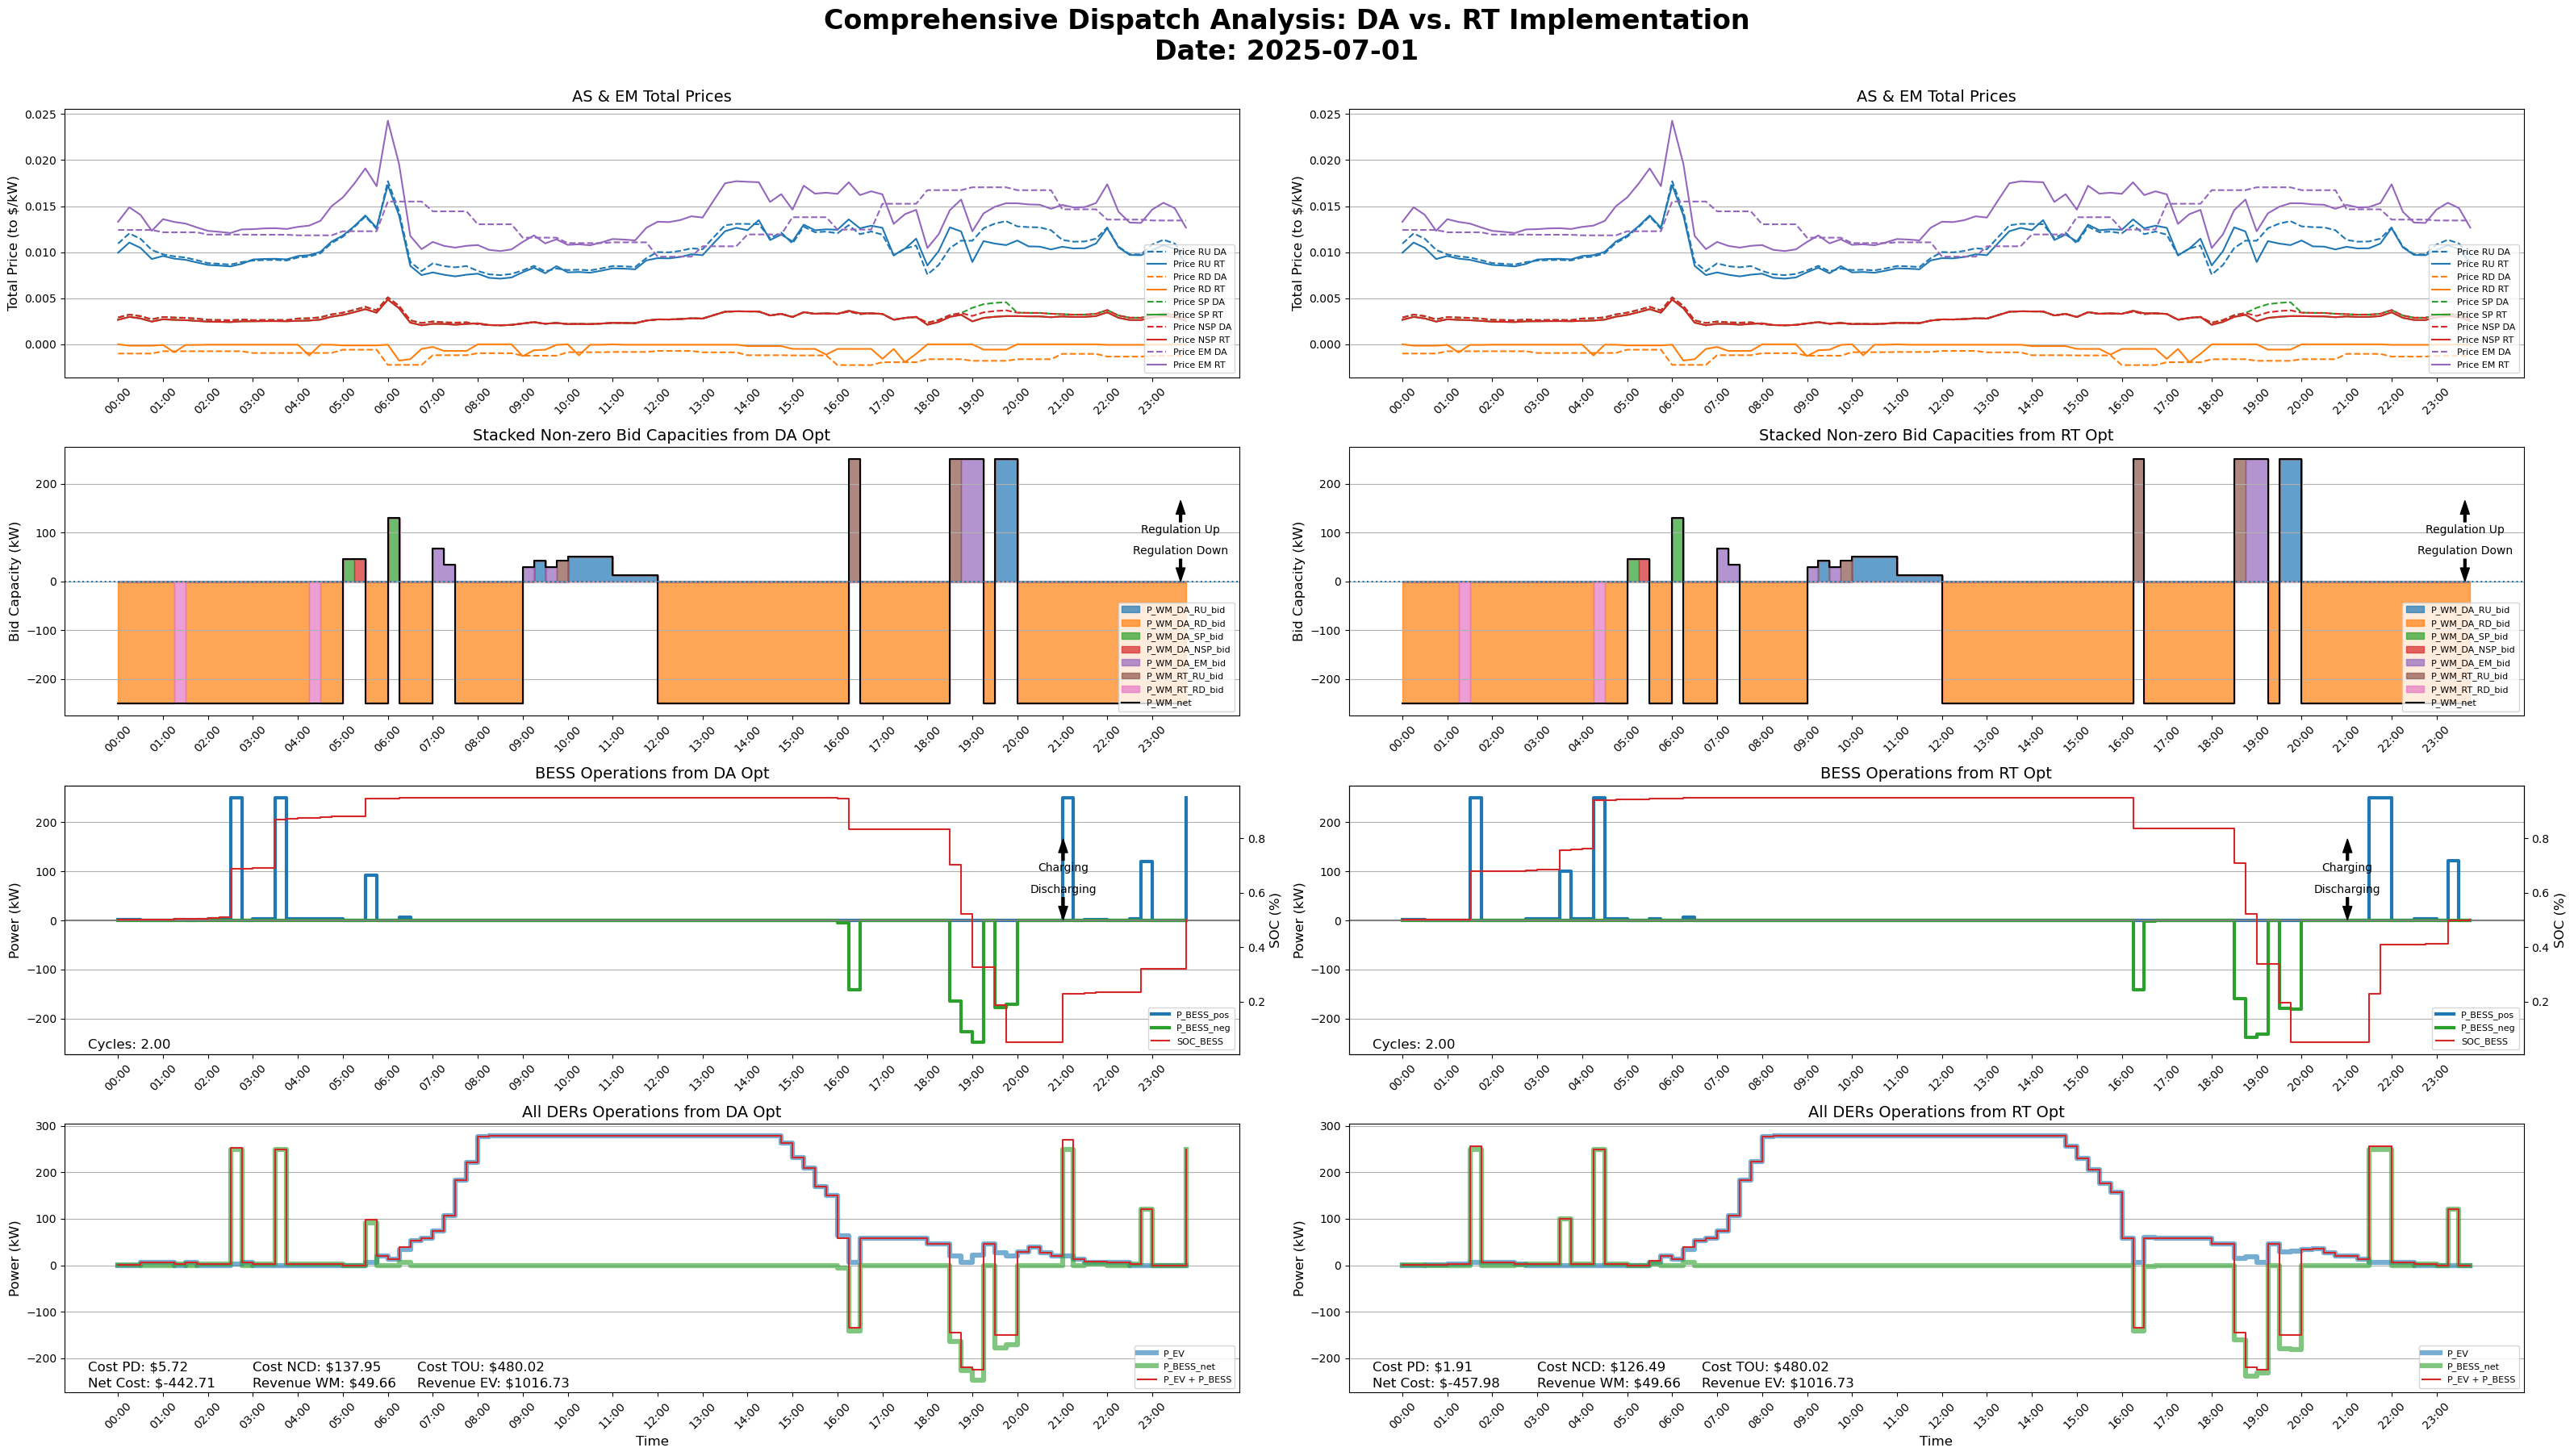

In [57]:
# NOTE: Plotting prices and capacities from DA and RT optimization results

# DA and RT are dispatches of the same day (Day0), so time index is the same
time_index_RT = pd.date_range(start=TheDate_Day0, periods=96, freq='15min')  # 96 intervals
t_RT = np.arange(len(time_index_RT))
hour_indices = np.arange(0, len(t_RT), 4)  # 4 * 15min = 1 hour
hour_labels = [time_index_RT[i].strftime('%H:%M') for i in hour_indices]

n_rows = 4
n_cols = 2
fig = plt.figure(figsize=(32, 18))
plt.subplots_adjust(hspace=0.15, wspace=0.15)
fig.suptitle(f"Comprehensive Dispatch Analysis: DA vs. RT Implementation\nDate: {TheDate_Day0.strftime('%Y-%m-%d')}", 
             fontsize=title_fontsize + 10, fontweight='bold', y=1.00)
optimizers = ['DA', 'RT']
solver_outputs = [Solver_Outputs_DA, Solver_Outputs_RT_Base]
axes_tracker = {}

# The total prices for each product, and Revenue_WM = sum of (price * capacity)
price_RU_DA = Bid_Pr_RT * alpha_RU_DA * dt_h + AS_Pr_RU_DA * dt_h
price_RU_RT = Bid_Pr_RT * alpha_RU_DA * dt_h + AS_Pr_RU_RT * dt_h
price_RD_DA = Bid_Pr_RT * alpha_RD_DA * dt_h - AS_Pr_RD_DA * dt_h
price_RD_RT = Bid_Pr_RT * alpha_RD_DA * dt_h - AS_Pr_RD_RT * dt_h
price_SP_DA = Bid_Pr_RT * alpha_SP_DA * dt_h + AS_Pr_SP_DA * dt_h
price_SP_RT = Bid_Pr_RT * alpha_SP_DA * dt_h + AS_Pr_SP_RT * dt_h
price_NSP_DA = Bid_Pr_RT * alpha_NSP_DA * dt_h + AS_Pr_NSP_DA * dt_h
price_NSP_RT = Bid_Pr_RT * alpha_NSP_DA * dt_h + AS_Pr_NSP_RT * dt_h
price_EM_DA = Bid_Pr_DA * dt_h
price_EM_RT = Bid_Pr_RT * dt_h

# plot total prices
def plot_total_prices(optimizer):
    plt.subplot(n_rows, n_cols, optimizers.index(optimizer) + 1)
    plt.plot(t_RT, price_RU_DA, label='Price RU DA', color=palette[0], linestyle='--', linewidth=linewidth)
    plt.plot(t_RT, price_RU_RT, label='Price RU RT', color=palette[0], linestyle='-', linewidth=linewidth)
    plt.plot(t_RT, price_RD_DA, label='Price RD DA', color=palette[1], linestyle='--', linewidth=linewidth)
    plt.plot(t_RT, price_RD_RT, label='Price RD RT', color=palette[1], linestyle='-', linewidth=linewidth)
    plt.plot(t_RT, price_SP_DA, label='Price SP DA', color=palette[2], linestyle='--', linewidth=linewidth)
    plt.plot(t_RT, price_SP_RT, label='Price SP RT', color=palette[2], linestyle='-', linewidth=linewidth)
    plt.plot(t_RT, price_NSP_DA, label='Price NSP DA', color=palette[3], linestyle='--', linewidth=linewidth)
    plt.plot(t_RT, price_NSP_RT, label='Price NSP RT', color=palette[3], linestyle='-', linewidth=linewidth)
    plt.plot(t_RT, price_EM_DA, label='Price EM DA', color=palette[4], linestyle='--', linewidth=linewidth)
    plt.plot(t_RT, price_EM_RT, label='Price EM RT', color=palette[4], linestyle='-', linewidth=linewidth)
    plt.xticks(hour_indices, hour_labels, rotation=45, fontsize=tick_fontsize) 
    plt.title('AS & EM Total Prices', fontsize=title_fontsize)
    plt.ylabel('Total Price (to $/kW)', fontsize=label_fontsize)
    plt.legend(loc='lower right', fontsize=legend_fontsize)
    plt.grid(axis ='y')


# plot stacked bar of non-zero bid capacities
def plot_stacked_bid_capacities(optimizer):
    col_idx = optimizers.index(optimizer)
    subplot_idx = (1 * n_cols) + col_idx + 1 # Row 1
    ax = plt.subplot(n_rows, n_cols, subplot_idx, sharey=axes_tracker.get(1) if col_idx == 1 else None)
    if col_idx == 0: axes_tracker[1] = ax
    wm_bid_labels = [
        'P_WM_DA_RU_bid', 'P_WM_DA_RD_bid', 'P_WM_DA_SP_bid', 'P_WM_DA_NSP_bid', 'P_WM_DA_EM_bid',
        'P_WM_RT_RU_bid', 'P_WM_RT_RD_bid', 'P_WM_RT_SP_bid', 'P_WM_RT_NSP_bid', 'P_WM_RT_EM_bid'
    ]
    # keep only nonzero series
    data_dict = {
        label: solver_outputs[optimizers.index(optimizer)][label]
        for label in wm_bid_labels
        if np.any(solver_outputs[optimizers.index(optimizer)][label] != 0)
    }
    labels = list(data_dict.keys())
    colors = palette[:len(labels)]
    # Initialize cumulative positive and negative bottoms
    bottom_pos = np.zeros_like(t_RT, dtype=float)
    bottom_neg = np.zeros_like(t_RT, dtype=float)
    for label, color in zip(labels, colors):
        values = np.array(data_dict[label])
        pos = np.where(values > 0, values, 0)
        neg = np.where(values < 0, values, 0)
        # Add legend only once per series
        plotted = False
        if np.any(pos):
            plt.fill_between(
                t_RT,
                bottom_pos,
                bottom_pos + pos,
                step='post',
                color=color,
                alpha=0.7,
                label=label  # show in legend
            )
            bottom_pos += pos
            plotted = True
        if np.any(neg):
            plt.fill_between(
                t_RT,
                bottom_neg,
                bottom_neg + neg,
                step='post',
                color=color,
                alpha=0.7,
                label=label if not plotted else None  # avoid duplicate
            )
            bottom_neg += neg
    # Black line = net sum of all series at each time
    net_sum = bottom_pos + bottom_neg
    plt.step(t_RT, net_sum, where='post', color='k', linewidth=1.5, label='P_WM_net')
    plt.axhline(0, linestyle=':')
    plt.xticks(hour_indices, hour_labels, rotation=45, fontsize=tick_fontsize)
    plt.ylabel('Bid Capacity (kW)', fontsize=label_fontsize)
    plt.title('Stacked Non-zero Bid Capacities from ' + optimizer + ' Opt', fontsize=title_fontsize)
    plt.legend(loc='lower right', fontsize=legend_fontsize)
    plt.grid(axis='y')
    arrow_pos = 0.95
    plt.annotate('Regulation Up', xy=(arrow_pos, 0.8), xycoords='axes fraction',
                xytext=(arrow_pos, 0.68), textcoords='axes fraction',
                arrowprops=dict(facecolor='black', edgecolor='black', width=2, headwidth=8),
                ha='center')
    plt.annotate('Regulation Down', xy=(arrow_pos, 0.5), xycoords='axes fraction',
                xytext=(arrow_pos, 0.6), textcoords='axes fraction',
                arrowprops=dict(facecolor='black', edgecolor='black', width=2, headwidth=8),
                ha='center')


# plot BESS operations
def plot_BESS_operations(optimizer):
    col_idx = optimizers.index(optimizer)
    subplot_idx = (2 * n_cols) + col_idx + 1 # Row 2
    ax1 = plt.subplot(n_rows, n_cols, subplot_idx, sharey=axes_tracker.get(2) if col_idx == 1 else None)
    if col_idx == 0: axes_tracker[2] = ax1
    ax1.step(t_RT, solver_outputs[optimizers.index(optimizer)]['P_BESS_pos'], label='P_BESS_pos', color=palette[0], where='post', linewidth=2*linewidth, alpha=1)
    ax1.step(t_RT, solver_outputs[optimizers.index(optimizer)]['P_BESS_neg'], label='P_BESS_neg', color=palette[2], where='post', linewidth=2*linewidth, alpha=1)
    plt.axhline(0, linestyle='-', color='gray')
    ax1.set_ylabel('Power (kW)', fontsize=label_fontsize)
    ax1.grid(axis='y')
    ax1.set_xticks(hour_indices)
    ax1.set_xticklabels(hour_labels, rotation=45, fontsize=tick_fontsize)
    ax2 = ax1.twinx()
    ax2.step(t_RT, solver_outputs[optimizers.index(optimizer)]['SOC_BESS'], label='SOC_BESS', color=palette[3], where='post', linewidth=1*linewidth)
    ax2.set_ylabel('SOC (%)', fontsize=label_fontsize)
    ax1.set_title('BESS Operations from ' + optimizer + ' Opt', fontsize=title_fontsize)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=legend_fontsize)
    arrow_pos = 0.85
    plt.annotate('Charging', xy=(arrow_pos, 0.8), xycoords='axes fraction',
                xytext=(arrow_pos, 0.68), textcoords='axes fraction',
                arrowprops=dict(facecolor='black', edgecolor='black', width=2, headwidth=8),
                ha='center')
    plt.annotate('Discharging', xy=(arrow_pos, 0.5), xycoords='axes fraction',
                xytext=(arrow_pos, 0.6), textcoords='axes fraction',
                arrowprops=dict(facecolor='black', edgecolor='black', width=2, headwidth=8),
                ha='center')
    # add cycle number
    cycles_BESS_DA = np.sum(np.abs(np.diff(solver_outputs[optimizers.index(optimizer)]['SOC_BESS']))) / (SOC_BESS_max - SOC_BESS_min)
    plt.annotate(f'Cycles: {cycles_BESS_DA:.2f}', xy=(0.02, 0.02), xycoords='axes fraction', fontsize=label_fontsize, ha='left')

# plot EV and BESS operations
def plot_EV_BESS_operations(optimizer):
    col_idx = optimizers.index(optimizer)
    subplot_idx = (3 * n_cols) + col_idx + 1 # Row 3
    ax = plt.subplot(n_rows, n_cols, subplot_idx, sharey=axes_tracker.get(3) if col_idx == 1 else None)
    if col_idx == 0: axes_tracker[3] = ax
    plt.step(t_RT, solver_outputs[optimizers.index(optimizer)]['P_EV'], label='P_EV', color=palette[0], where='post', linewidth=3*linewidth, alpha=0.6)
    plt.step(t_RT, solver_outputs[optimizers.index(optimizer)]['P_BESS_pos'] + solver_outputs[optimizers.index(optimizer)]['P_BESS_neg'], label='P_BESS_net', color=palette[2], where='post', linewidth=3*linewidth, alpha=0.6)
    plt.step(t_RT, solver_outputs[optimizers.index(optimizer)]['P_GI'], label='P_EV + P_BESS', color=palette[3], where='post', linewidth=1*linewidth, alpha=1)
    plt.ylabel('Power (kW)', fontsize=label_fontsize)
    plt.grid(axis='y')
    plt.xticks(hour_indices, hour_labels, rotation=45, fontsize=tick_fontsize)
    plt.title('All DERs Operations from ' + optimizer + ' Opt', fontsize=title_fontsize)
    plt.xlabel('Time', fontsize=label_fontsize)
    plt.legend(loc='lower right', fontsize=legend_fontsize)
    # add cost and revenue
    rows = [
        [("Net Cost", "Cost_Opt"), ("Revenue WM", "Revenue_WM"), ("Revenue EV", "Revenue_EV")],
        [("Cost PD", "Cost_PD"), ("Cost NCD", "Cost_NCD"), ("Cost TOU", "Cost_TOU")],
    ]
    x_pos = [0.02, 0.16, 0.30]
    y_pos = [0.02, 0.08]
    for y, row in zip(y_pos, rows):
        for x, (text, key) in zip(x_pos, row):
            if optimizer == 'DA':
                plt.annotate(
                f"{text}: ${solver_outputs[optimizers.index(optimizer)][key]:.2f}",
                xy=(x, y), xycoords="axes fraction", fontsize=label_fontsize, ha="left",
            )
            else:
                plt.annotate(
                f"{text}: ${solver_outputs[optimizers.index(optimizer)][key].sum():.2f}",
                xy=(x, y), xycoords="axes fraction", fontsize=label_fontsize, ha="left",
            )

# --- Execute Plotting ---
for i, opt in enumerate(optimizers):
    plot_total_prices(opt)
    plot_stacked_bid_capacities(opt)
    plot_BESS_operations(opt)
    plot_EV_BESS_operations(opt)

# save figure
plt.tight_layout()
path = 'Results/Plots/Operation_Per_Product/' + \
            TheDate_Day0.strftime("%Y")+'_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival + '/'

os.makedirs(path, exist_ok=True)
plt.savefig(path + TheDate_Day0.strftime("%Y%m%d") + '_Solver_Outputs.pdf', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()
plt.close()


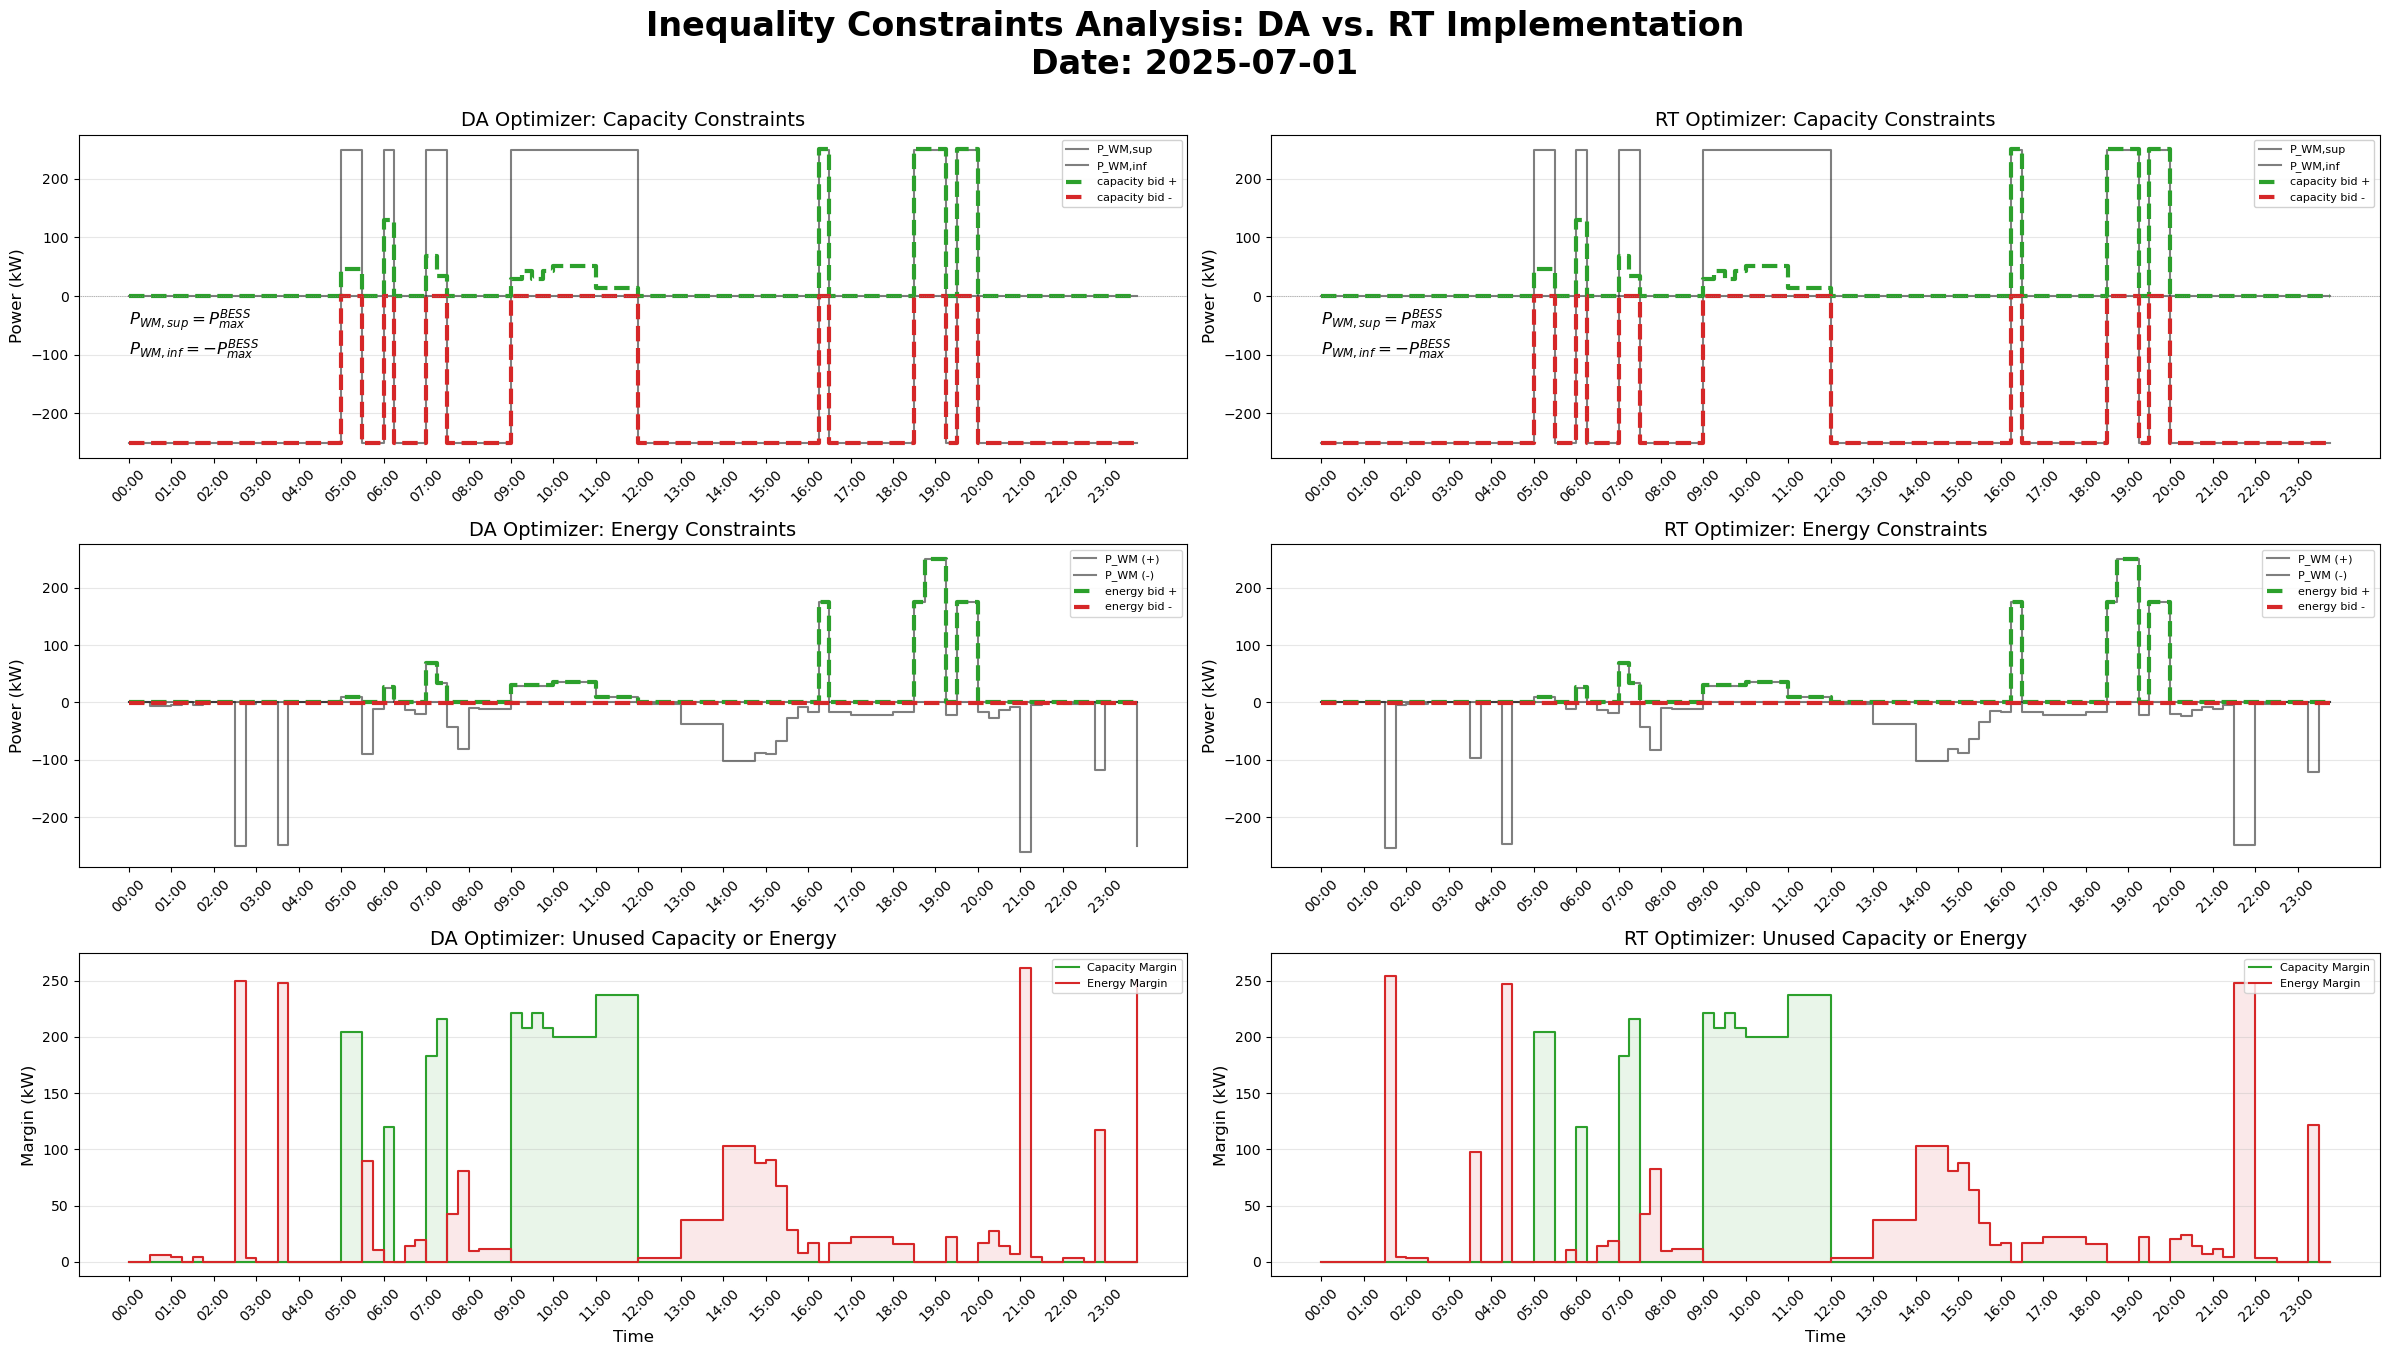

In [ ]:
# NOTE: Plotting Inequality Constraints (Capacity and Energy) following the former style

# Initialization
time_index_RT = pd.date_range(start=TheDate_Day0, periods=96, freq='15min')
t_RT = np.arange(len(time_index_RT))
hour_indices = np.arange(0, len(t_RT), 4)
hour_labels = [time_index_RT[i].strftime('%H:%M') for i in hour_indices]

n_rows = 3 # Focusing on Capacity and Energy
n_cols = 2 # DA and RT
fig = plt.figure(figsize=(16*1.5, 9*1.5))
plt.subplots_adjust(hspace=0.2, wspace=0.15)
fig.suptitle(f"Inequality Constraints Analysis: DA vs. RT Implementation\nDate: {TheDate_Day0.strftime('%Y-%m-%d')}", 
             fontsize=title_fontsize + 10, fontweight='bold', y=1.00)

optimizers = ['DA', 'RT']
solver_outputs = [Solver_Outputs_DA, Solver_Outputs_RT_Base]
axes_tracker_ineq = {}

def plot_capacity_constraints(optimizer):
    col_idx = optimizers.index(optimizer)
    subplot_idx = col_idx + 1 
    ax = plt.subplot(n_rows, n_cols, subplot_idx, sharey=axes_tracker_ineq.get(0) if col_idx == 1 else None)
    if col_idx == 0: axes_tracker_ineq[0] = ax
    
    out = solver_outputs[col_idx]
    eps = 0.5 # Small offset in kW to separate overlapping lines

    P_EM_pos_combo = np.maximum(out['P_WM_DA_EM_bid'], 0) + np.maximum(out['P_WM_RT_EM_bid'], 0)
    P_EM_neg_combo = np.minimum(out['P_WM_DA_EM_bid'], 0) + np.minimum(out['P_WM_RT_EM_bid'], 0)
    
    # 1. Plot Hardware Limits with a distinct style
    plt.step(t_RT, out['P_WM_sup'], label='P_WM,sup', color='black', linewidth=linewidth*1, alpha=0.5, where='post', linestyle='-')
    plt.step(t_RT, out['P_WM_inf'], label='P_WM,inf', color='black', linewidth=linewidth*1, alpha=0.5, where='post', linestyle='-')
    plt.annotate(r'$P_{WM,sup} = P^{BESS}_{max}$' + '\n' + r'$P_{WM,inf} = - P^{BESS}_{max}$',
                 xy=(0, -100), xytext=(0, -100), fontsize=label_fontsize, fontweight='bold', color='black')

    # 2. RHS Calculation
    rhs_pos = (out['P_WM_DA_RU_bid'] + out['P_WM_RT_RU_bid'] + 
               out['P_WM_DA_SP_bid'] + out['P_WM_RT_SP_bid'] + 
               out['P_WM_DA_NSP_bid'] + out['P_WM_RT_NSP_bid'] + P_EM_pos_combo)
    rhs_neg = (out['P_WM_DA_RD_bid'] + out['P_WM_RT_RD_bid'] + P_EM_neg_combo)

    # 3. Plot lines with small offsets to prevent overlap at 0
    plt.step(t_RT, rhs_pos + eps, where='post', label='capacity bid +', color=palette[2], linestyle='--', linewidth=linewidth*2)
    plt.step(t_RT, rhs_neg - eps, where='post', label='capacity bid -', color=palette[3], linestyle='--', linewidth=linewidth*2)

    plt.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    plt.xticks(hour_indices, hour_labels, rotation=45, fontsize=tick_fontsize)
    plt.title(optimizer + ' Optimizer: Capacity Constraints', fontsize=title_fontsize)
    plt.ylabel('Power (kW)', fontsize=label_fontsize)
    plt.legend(loc='upper right', fontsize=legend_fontsize, frameon=True, framealpha=0.9)
    plt.grid(axis='y', alpha=0.3)

def plot_energy_constraints(optimizer):
    col_idx = optimizers.index(optimizer)
    subplot_idx = n_cols + col_idx + 1 
    ax = plt.subplot(n_rows, n_cols, subplot_idx, sharey=axes_tracker_ineq.get(1) if col_idx == 1 else None)
    if col_idx == 0: axes_tracker_ineq[1] = ax
    
    out = solver_outputs[col_idx]
    eps = 0.5

    P_EM_pos_combo = np.maximum(out['P_WM_DA_EM_bid'], 0) + np.maximum(out['P_WM_RT_EM_bid'], 0)
    P_EM_neg_combo = np.minimum(out['P_WM_DA_EM_bid'], 0) + np.minimum(out['P_WM_RT_EM_bid'], 0)
    
    # Effective Power Components
    plt.step(t_RT, out['P_WM_pos'], label='P_WM (+)', color='black', where='post', linewidth=linewidth*1, alpha=0.5)
    plt.step(t_RT, out['P_WM_neg'], label='P_WM (-)', color='black', where='post', linewidth=linewidth*1, alpha=0.5)

    # Constraint RHS
    rhs_pos = (alpha_RU_DA * (out['P_WM_DA_RU_bid'] + out['P_WM_RT_RU_bid']) + 
               alpha_SP_DA * (out['P_WM_DA_SP_bid'] + out['P_WM_RT_SP_bid']) + 
               alpha_NSP_DA * (out['P_WM_DA_NSP_bid'] + out['P_WM_RT_NSP_bid']) + P_EM_pos_combo)
    rhs_neg = (alpha_RD_DA * (out['P_WM_DA_RD_bid'] + out['P_WM_RT_RD_bid']) + P_EM_neg_combo)
    
    # Visualizing the Energy "Safety Envelope"
    plt.step(t_RT, rhs_pos + eps, where='post', label='energy bid +', color=palette[2], linestyle='--', linewidth=linewidth*2)
    plt.step(t_RT, rhs_neg - eps, where='post', label='energy bid -', color=palette[3], linestyle='--', linewidth=linewidth*2)

    plt.xticks(hour_indices, hour_labels, rotation=45, fontsize=tick_fontsize)
    plt.title(optimizer + ' Optimizer: Energy Constraints', fontsize=title_fontsize)
    plt.ylabel('Power (kW)', fontsize=label_fontsize)
    plt.legend(loc='upper right', fontsize=legend_fontsize)
    plt.grid(axis='y', alpha=0.3)
    
# plot constraint margins (Slack)
def plot_constraint_margins(optimizer):
    col_idx = optimizers.index(optimizer)
    subplot_idx = (2 * n_cols) + col_idx + 1 
    ax = plt.subplot(n_rows, n_cols, subplot_idx, 
                     sharey=axes_tracker_ineq.get(2) if col_idx == 1 else None)
    if col_idx == 0: axes_tracker_ineq[2] = ax
    
    out = solver_outputs[col_idx]
    z = out['z_WM'] # 1 for Pos, 0 for Neg
    
    # 1. Recalculate Combined Bids (Consistent with your logic)
    P_EM_pos_combo = np.maximum(out['P_WM_DA_EM_bid'], 0) + np.maximum(out['P_WM_RT_EM_bid'], 0)
    P_EM_neg_combo = np.minimum(out['P_WM_DA_EM_bid'], 0) + np.minimum(out['P_WM_RT_EM_bid'], 0)

    # 2. Calculate RHS
    rhs_cap_pos = (out['P_WM_DA_RU_bid'] + out['P_WM_RT_RU_bid'] + 
                   out['P_WM_DA_SP_bid'] + out['P_WM_RT_SP_bid'] + 
                   out['P_WM_DA_NSP_bid'] + out['P_WM_RT_NSP_bid'] + P_EM_pos_combo)
    rhs_cap_neg = (out['P_WM_DA_RD_bid'] + out['P_WM_RT_RD_bid'] + P_EM_neg_combo)

    rhs_ene_pos = (alpha_RU_DA * (out['P_WM_DA_RU_bid'] + out['P_WM_RT_RU_bid']) + 
                   alpha_SP_DA * (out['P_WM_DA_SP_bid'] + out['P_WM_RT_SP_bid']) + 
                   alpha_NSP_DA * (out['P_WM_DA_NSP_bid'] + out['P_WM_RT_NSP_bid']) + P_EM_pos_combo)
    rhs_ene_neg = (alpha_RD_DA * (out['P_WM_DA_RD_bid'] + out['P_WM_RT_RD_bid']) + P_EM_neg_combo)

    # 3. Calculate Differences based on z_WM
    # Margin = Limit - Actual (We want this to be >= 0)
    diff_cap = np.where(z == 1, out['P_WM_sup'] - rhs_cap_pos, rhs_cap_neg - out['P_WM_inf'])
    diff_ene = np.where(z == 1, out['P_WM_pos'] - rhs_ene_pos, rhs_ene_neg - out['P_WM_neg'])

    # 4. Plotting
    plt.step(t_RT, diff_cap, where='post', label='Capacity Margin', color=palette[2], linewidth=linewidth)
    plt.step(t_RT, diff_ene, where='post', label='Energy Margin', color=palette[3], linewidth=linewidth)
    
    # Fill the 'Tightness' area - if margin is close to 0, the constraint is active
    plt.fill_between(t_RT, 0, diff_cap, step='post', color=palette[2], alpha=0.1)
    plt.fill_between(t_RT, 0, diff_ene, step='post', color=palette[3], alpha=0.1)
    plt.xticks(hour_indices, hour_labels, rotation=45, fontsize=tick_fontsize)
    plt.title(f'{optimizer} Optimizer: Unused Capacity or Energy', fontsize=title_fontsize)
    plt.ylabel('Margin (kW)', fontsize=label_fontsize)
    plt.xlabel('Time', fontsize=label_fontsize)
    plt.legend(loc='upper right', fontsize=legend_fontsize)
    plt.grid(axis='y', alpha=0.3)


# Execute Plotting
for i, opt in enumerate(optimizers):
    plot_capacity_constraints(opt)
    plot_energy_constraints(opt)
    plot_constraint_margins(opt)

# Save figure (Following your directory structure)
plt.tight_layout()
path_ineq = 'Results/Plots/Inequality_Analysis/' + \
            TheDate_Day0.strftime("%Y")+'_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival + '/'
os.makedirs(path_ineq, exist_ok=True)
plt.savefig(path_ineq + TheDate_Day0.strftime("%Y%m%d") + '_Inequality_Constraints.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()
plt.close()

In [ ]:
# Old Stairplot
xmin = pd.to_datetime(TimeSeries_real[0][0])
xmax = pd.to_datetime(TimeSeries_real[0][-1]+timedelta(minutes=dt_m_EV))
ymin = -15
ymax = 46
ymax_pw = 505
xmin_ZoomIn = pd.to_datetime(TimeSeries_real[0][64])
xmax_ZoomIn = pd.to_datetime(TimeSeries_real[0][84])
ymin_ZoomIn = -5
ymax_ZoomIn = 20           

t = pd.to_datetime(TimeSeries_real[0]) + timedelta(minutes=dt_m_EV/2)            
t2 = TimeSeries_real[0].copy()
t2.append(TimeSeries_real[0][-1] + timedelta(minutes=dt_m_EV))
length_t3 = 5
t3 = t2[0:length_t3]  # for short time series lines

Pw_V0G_max = EnergyDemand_Step_V0G_TheDates[0]/dt_h
Pw_V1G = EnergyDemand_Step_V1G_TheDates[0]/dt_h
Pw_Opt_Offline = pd.Series(P_GI_DA)
Pw_Opt_t0 = pd.Series(dispatch_t0[0])
Pw_Opt_Imp_base = (Dispatch[0][0].sum(axis=1))/dt_h + P_BESS_value_RT[0, :]
Pw_Opt_Imp_case1 = (Dispatch[0][1].sum(axis=1))/dt_h + P_BESS_value_RT[1, :]
Pw_Baseline_Base = pd.Series(Baseline_96[0].reshape(96)/dt_h)
Pw_Baseline_Case1 = pd.Series(Baseline_96[1].reshape(96)/dt_h)
Event_Base  = np.array(EventHour_96[0])*500 - 5
Event_Case1 = np.array(EventHour_96[1])*500 - 5

Pw_V0G_max_stair       = pd.concat([pd.Series(Pw_V0G_max[0])      ,Pw_V0G_max])
Pw_V1G_stair           = pd.concat([pd.Series(Pw_V1G[0])          ,Pw_V1G])
Pw_Opt_Offline_stair   = pd.concat([pd.Series(Pw_Opt_Offline[0])  ,Pw_Opt_Offline])
Pw_Opt_t0_stair        = pd.concat([pd.Series(Pw_Opt_t0[0])       ,Pw_Opt_t0])
Pw_Opt_Imp_base_stair  = pd.concat([pd.Series(Pw_Opt_Imp_base[0]) ,Pw_Opt_Imp_base])
Pw_Opt_Imp_case1_stair = pd.concat([pd.Series(Pw_Opt_Imp_case1[0]),Pw_Opt_Imp_case1])
Pw_Baseline_Base_stair  = pd.concat([pd.Series(Pw_Baseline_Base[0]) ,Pw_Baseline_Base])
Pw_Baseline_Case1_stair = pd.concat([pd.Series(Pw_Baseline_Case1[0]),Pw_Baseline_Case1])

# Simplified: NCD threshold for base case (stair plot)
M_Pw_NCD_start_Base_stair = pd.Series([D_Th_NCD_96[0][0]] * length_t3)
M_Pw_NCD_start_Case1_stair = pd.Series([D_Th_NCD_96[1][0]] * length_t3)
M_Pw_PD_start_Base_stair   = pd.Series([D_Th_PD_96[0][0]] * length_t3)
M_Pw_PD_start_Case1_stair  = pd.Series([D_Th_PD_96[1][0]] * length_t3)


# Plotting
plt.figure(figsize=(16, 9)) 
V0G,          = plt.step(t2, Pw_V0G_max_stair      , linestyle='-', color='seagreen', linewidth=2)
V1G,          = plt.step(t2, Pw_V1G_stair          , linestyle='-',  color='olive', linewidth=2)
Opt_DA,       = plt.step(t2, Pw_Opt_Offline_stair  , linestyle='-', color='tab:blue', linewidth=4)
Opt_t0,       = plt.step(t2, Pw_Opt_t0_stair       , linestyle='-',  color='deepskyblue', linewidth=4) 
Opt_Imp_base, = plt.step(t2, Pw_Opt_Imp_base_stair , linestyle='--',  color='tab:red', linewidth=2)
Opt_Imp_case1,= plt.step(t2, Pw_Opt_Imp_case1_stair, linestyle='--', color='lightcoral', linewidth=2)
Baseline_base , = plt.step(t2, Pw_Baseline_Base_stair , linestyle='--', color='navy', linewidth=2)
Baseline_case1,  = plt.step(t2, Pw_Baseline_Case1_stair, linestyle='--', color='royalblue', linewidth=2)

# Plot the short timeseries lines
NCD_start_base,  = plt.step(t3, M_Pw_NCD_start_Base_stair, linestyle='', marker='8', color='tab:orange', markersize=5)
NCD_start_case1, = plt.step(t3, M_Pw_NCD_start_Case1_stair, linestyle='', marker='>', color='seagreen', markersize=3)
PD_start_base,   = plt.step(t3, M_Pw_PD_start_Base_stair, linestyle='', marker='s', color='tab:orange', markersize=5)
PD_start_case1,  = plt.step(t3, M_Pw_PD_start_Case1_stair, linestyle='', marker='<', color='seagreen', markersize=3)
Event_base,   = plt.plot(TimeSeries_real[0], Event_Base, linestyle='', marker='x', color='tab:red', markersize=5)
Event_case1,  = plt.plot(TimeSeries_real[0], Event_Case1, linestyle='', marker='+', color='seagreen', markersize=3)

# Create a separate legend for these short timeseries
short_handles = [NCD_start_base, NCD_start_case1, PD_start_base, PD_start_case1, Event_base, Event_case1]
short_labels = [
    r'$NCD_{opt,imp,100\%}$ (short)', 
    r'$NCD_{opt,imp,\eta \%}$ (short)', 
    r'$PD_{opt,imp,100\%}$ (short)', 
    r'$PD_{opt,imp,\eta \%}$ (short)',
    r'$event hour_{opt,imp,100\%}$ (short)',
    r'$event hour_{opt,imp,\eta \%}$ (short)'
]

legend1 = plt.legend(
    short_handles, short_labels,
    loc='upper right',
    bbox_to_anchor=(1.05, 1),
    fontsize=12,
    ncol=1,
    frameon=False
)

plt.gca().add_artist(legend1)

# Main legend
plt.title("Off-line and Implemented EV + BESS scheduling on " + H_Start_RT.strftime("%Y/%m/%d "), fontsize=16)
plt.xlabel('Time [-]', fontsize=16)
plt.ylabel('Power Demand [kW]', fontsize=16)
plt.legend([Baseline_base, Baseline_case1, Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G, V1G],\
            [r'$baseline_{100\%}$', r'$baseline_{\eta\%}$', r'$V1G_{opt,DA,100\%}$', r'$V1G_{opt,RT,t0,100\%}$',\
            r'$V1G_{opt,imp,100\%}$', r'$V1G_{opt,imp,\eta\%}$', r'$V0G_{100\%}$',   r'$V1G_{real,100\%}$'],
bbox_to_anchor=(1.05, 1),
loc='upper left',
ncol=1,
fontsize=12,
frameon=False)

plt.gca().set_facecolor('white')
plt.gcf().autofmt_xdate()
myFmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax_pw)

path = 'Results/Plots/Imp_Stair/'+H_Start_RT.strftime("%Y")+'_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival + '/'

os.makedirs(path, exist_ok=True)
plt.tight_layout()
# plt.savefig(path  + H_Start_RT.strftime("%Y%m%d") + '_Implemented_Pw_stair.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()
plt.close()

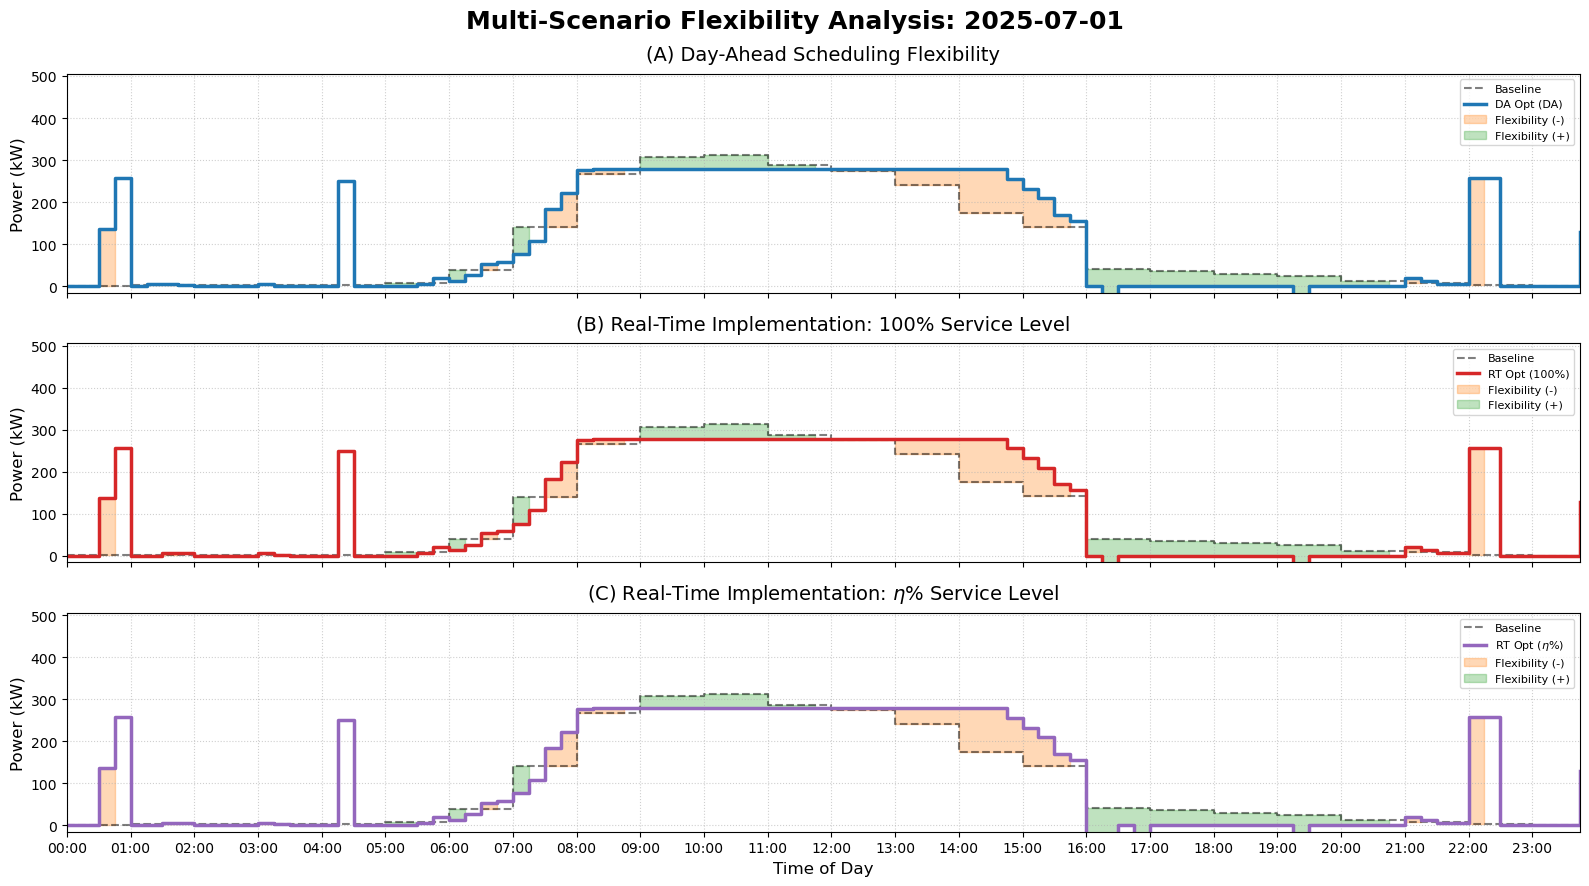

In [ ]:
# Data for Flexibility Plot # TODO: different baseline plots, not all in one
y_baseline_da = Solver_Outputs_DA['Baseline(kW)']
y_baseline_100 = Solver_Outputs_RT_Base['Baseline(kW)']
y_baseline_eta = Solver_Outputs_RT_Case1['Baseline(kW)']
y_da_GI = Solver_Outputs_DA['P_GI']
y_rt_GI_100 = Solver_Outputs_RT_Base['P_GI']
y_rt_GI_eta = Solver_Outputs_RT_Case1['P_GI']
y_da_EV = Solver_Outputs_DA['P_EV']
y_rt_EV_100 = Solver_Outputs_RT_Base['P_EV']
y_rt_EV_eta = Solver_Outputs_RT_Case1['P_EV']

time_index = pd.to_datetime(TimeSeries_real[0])

# --- Configuration ---
c_base = 'black'
c_da = palette[0]      # Blue
c_100 = palette[3]     # Red
c_eta = palette[4]     # Purple
c_fill_up = palette[1] # Orange
c_fill_down = palette[2] # Green

legend_style = {
    'loc': 'upper right',
    'ncol': 1,
    'fontsize': legend_fontsize,
    'frameon': True,
    'facecolor': 'white',
    'framealpha': 0.8
}

# --- Plotting (3 Rows, 1 Column) ---
fig, axs = plt.subplots(3, 1, figsize=(16, 9), sharex=True, sharey=True)
# Add a Super-Title with the Date Info
fig.suptitle(f"Multi-Scenario Flexibility Analysis: {H_Start_RT.strftime('%Y-%m-%d')}", 
             fontsize=title_fontsize + 4, fontweight='bold', y=0.98)

def finalize_subplot(ax, title):
    ax.set_title(title, fontsize=title_fontsize, pad=10)
    ax.set_ylabel("Power (kW)", fontsize=label_fontsize)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(time_index[0], time_index[-1])
    ax.set_ylim(ymin, ymax_pw)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

def plot_flex_interaction(ax, y_base, y_gi, label_gi, color_gi):
    # Baseline
    ax.step(time_index, y_base, color=c_base, linestyle='--', alpha=0.5, label='Baseline', where='post')
    # Grid Impact (GI)
    ax.step(time_index, y_gi, color=color_gi, linewidth=2.5, label=label_gi, where='post')
    
    # Shade Flexibility Areas
    ax.fill_between(time_index, y_base, y_gi, where=(y_gi >= y_base), 
                    step='post', color=c_fill_up, alpha=0.3, label='Flexibility (-)')
    ax.fill_between(time_index, y_base, y_gi, where=(y_gi < y_base), 
                    step='post', color=c_fill_down, alpha=0.3, label='Flexibility (+)')

# --- Subplot 1: DA Planning ---
plot_flex_interaction(axs[0], y_baseline_da, y_da_GI, 'DA Opt (DA)', c_da)
finalize_subplot(axs[0], "(A) Day-Ahead Scheduling Flexibility")
axs[0].legend(**legend_style)
# --- Subplot 2: RT 100% ---
plot_flex_interaction(axs[1], y_baseline_100, y_rt_GI_100, 'RT Opt (100%)', c_100)
finalize_subplot(axs[1], "(B) Real-Time Implementation: 100% Service Level")
axs[1].legend(**legend_style)
# --- Subplot 3: RT eta% ---
plot_flex_interaction(axs[2], y_baseline_eta, y_rt_GI_eta, r'RT Opt ($\eta$%)', c_eta)
finalize_subplot(axs[2], r"(C) Real-Time Implementation: $\eta$% Service Level")
axs[2].legend(**legend_style)
# --- Final X-axis Labeling ---
axs[2].set_xlabel("Time of Day", fontsize=label_fontsize)
plt.setp(axs[2].get_xticklabels(), rotation=0) # Keep horizontal for clarity if space allows

# Save Figure
path = 'Results/Plots/Imp_Flexibility/'+H_Start_RT.strftime("%Y")+'_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival + '/'
os.makedirs(path, exist_ok=True)
plt.tight_layout()
plt.savefig(path + H_Start_RT.strftime("%Y%m%d") + '_Implemented_Flex.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()